# Flow Matching on the 2D Checkerboard

**Phase 2 of the Flow Matching replication** (Lipman et al., 2022, *Flow Matching for Generative Modeling*, arXiv:2210.02747).

This notebook reuses the Phase-1 (8-Gaussian) pipeline almost unchanged and applies it to the **2D checkerboard**, the toy density used in the paper's Figure 4 (left). The goal is to reproduce the paper's central claims on a *different* target:

- **FM-OT** — Flow Matching with the Optimal-Transport conditional path (eq. 20–23).
- **FM-Diff** — Flow Matching with the Variance-Preserving diffusion path (eq. 18–19).
- **SM-Diff** — Score Matching with the VP path (eq. 42–43) — added later, for the H3 stability comparison.

> **Key point: the ODEs and probability paths do *not* change.**
> The FM-OT and VP paths are defined only by the source `N(0, I)` and a single data endpoint `x1`; they never reference *what* the data distribution is. So the conditional paths, target velocity fields, CFM objective, the network, and all ODE solvers are carried over verbatim. Only the **target sampler** and the **evaluation metrics** change — the checkerboard has no discrete modes, so the mode-based metrics from Phase 1 are replaced by cell/support-based ones.

## Research questions and hypotheses

**Main question.** Do FM-OT, FM-Diff, and SM-Diff, trained under identical architecture and optimisation settings, reproduce the paper's findings on the checkerboard as they did on the 8-Gaussian ring?

**Hypotheses** (adapted from Phase 1; H5 is new and checkerboard-specific):

- **H1 — Support recovery.** At high sampling accuracy, all methods reproduce the full checkerboard support (all "on" cells populated, "off" cells empty).
- **H2 — OT sampling efficiency.** FM-OT preserves distribution quality better at low NFE (on-support rate, MMD², sliced-Wasserstein), because its conditional paths are straight, constant-velocity trajectories.
- **H3 — FM vs SM stability.** FM-Diff trains more stably than SM-Diff on the same VP path (pending SM-Diff).
- **H4 — High-NFE convergence.** Method differences shrink once the ODE is solved accurately.
- **H5 — Pattern emergence (new).** The OT path introduces the checkerboard pattern *earlier* along the generative trajectory than the diffusion path (a direct mirror of Fig. 4, left). We test this by measuring on-support rate at intermediate times `t`.

## 1. Environment and configuration

Standard imports. The pipeline is 2D, so it is light enough to run on CPU, but CUDA is used when available (matching Phase 1).

In [211]:
import math
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Use CUDA when available; the whole pipeline is tiny so CPU also works.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.13.0+cu130
Device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [212]:
# ---- Reproducibility ----
SEED = 42
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision("high")  # faster matmuls on recent GPUs

# ---- Model / optimisation config (identical to Phase 1) ----
DATA_DIM              = 2        # 2D toy data
HIDDEN_DIM            = 512      # MLP width  (paper: 512)
NUM_HIDDEN_LAYERS     = 5        # MLP depth  (paper: 5 hidden layers)
LEARNING_RATE         = 5e-4
NUM_TRAINING_STEPS    = 20_000
BATCH_SIZE            = 2_048    # training mini-batch (fresh samples each step)
VALIDATION_BATCH_SIZE = 4_096
LOG_EVERY             = 100
NUM_PLOT_SAMPLES      = 5_000

# ---- FM-OT config ----
# sigma_min is the residual std at the data endpoint of the OT path (eq. 20).
# Kept identical to Phase 1 so the two experiments are directly comparable.
SIGMA_MIN = 1e-4

print("Model: %d-dim data, %d hidden layers x %d units" % (DATA_DIM, NUM_HIDDEN_LAYERS, HIDDEN_DIM))
print("Training steps:", NUM_TRAINING_STEPS, "| batch:", BATCH_SIZE, "| lr:", LEARNING_RATE)
print("sigma_min:", SIGMA_MIN)

Model: 2-dim data, 5 hidden layers x 512 units
Training steps: 20000 | batch: 2048 | lr: 0.0005
sigma_min: 0.0001


## 2. The checkerboard target distribution

We define a **rigorous** version of the standard 2D checkerboard: the square domain
$[-L, L]^2$ (with $L = 4$) is partitioned into unit cells, and a cell is **"on"** when
$\lfloor x_1 \rfloor + \lfloor x_2 \rfloor$ is even. With $L = 4$ and unit cells there are
$8 \times 8 = 64$ cells, of which exactly **32 are "on"**.

The target density is **uniform on the union of the on-cells**:

$$
q(x) =
\begin{cases}
\dfrac{1}{N_{\text{on}} \cdot A_{\text{cell}}} = \dfrac{1}{32 \cdot 1} = \dfrac{1}{32}, & x \text{ on an on-cell},\\[6pt]
0, & \text{otherwise.}
\end{cases}
$$

Two consequences we will use throughout:

1. **Sampling is exact.** Pick an on-cell uniformly (each with probability $1/32$), then a point uniformly inside it. No rejection needed.
2. **Entropy floor.** The differential entropy of a uniform density on support of area $32$ is $\log 32 \approx 3.4657$ nats ($\approx 1.733$ nats/dim). This is the theoretical minimum for the model NLL.

> **Important caveat for later.** Unlike the Gaussian mixture, this floor is **not reachable** by a continuous CNF: a smooth vector field cannot map a Gaussian onto a density with sharp discontinuities at the cell boundaries. So even a near-perfect model will sit *slightly above* $\log 32$. The gap then measures boundary/smoothness leakage, not a defect — we interpret model NLL accordingly.

In [213]:
# ---- Checkerboard geometry ----
DOMAIN_LIMIT = 4.0     # domain is [-DOMAIN_LIMIT, DOMAIN_LIMIT]^2
CELL_SIZE    = 1.0     # unit cells

# Integer lower-corner indices of every cell: -4, -3, ..., 3  (8 values per axis).
_cell_indices = torch.arange(-DOMAIN_LIMIT, DOMAIN_LIMIT, CELL_SIZE)  # [-4, ..., 3]

# Build the list of "on"-cell lower corners: cell (i, j) is on iff (i + j) is even.
_on_corners = []
for i in _cell_indices:
    for j in _cell_indices:
        if int(i + j) % 2 == 0:                 # even -> "on" cell
            _on_corners.append((float(i), float(j)))

ON_CELL_CORNERS = torch.tensor(_on_corners, dtype=torch.float32)  # shape (N_on, 2)
NUM_ON_CELLS    = ON_CELL_CORNERS.shape[0]
SUPPORT_AREA    = NUM_ON_CELLS * (CELL_SIZE ** 2)
ENTROPY_FLOOR   = math.log(SUPPORT_AREA)         # differential entropy = -log density

print("On-cells:", NUM_ON_CELLS, "| support area:", SUPPORT_AREA)
print("Entropy floor (nats):    ", ENTROPY_FLOOR)
print("Entropy floor (nats/dim):", ENTROPY_FLOOR / DATA_DIM)

On-cells: 32 | support area: 32.0
Entropy floor (nats):     3.4657359027997265
Entropy floor (nats/dim): 1.7328679513998633


In [214]:
def on_checkerboard_support(x: torch.Tensor) -> torch.Tensor:
    """
    Boolean mask: True where x lies on an "on" cell of the checkerboard.

    A point is on-support iff it is inside the domain AND the integer cell it
    falls into, (floor(x1), floor(x2)), satisfies (floor(x1) + floor(x2)) even.
    """
    inside = (x.abs() <= DOMAIN_LIMIT).all(dim=-1)          # within [-L, L]^2
    cell   = torch.floor(x)                                 # integer cell index per point
    parity_even = ((cell[:, 0] + cell[:, 1]) % 2 == 0)      # "on" cells have even parity
    return inside & parity_even

In [215]:
def sample_checkerboard(n_samples: int, device: torch.device) -> torch.Tensor:
    """
    Exact sampler for the uniform checkerboard density.

    Step 1: choose an on-cell uniformly at random (each of the 32 with prob 1/32).
    Step 2: place the point uniformly inside that unit cell.
    """
    corners = ON_CELL_CORNERS.to(device)                    # (N_on, 2) lower corners
    # Uniformly pick one on-cell per sample.
    choice = torch.randint(0, NUM_ON_CELLS, (n_samples,), device=device)
    chosen_corner = corners[choice]                         # (n_samples, 2)
    # Uniform offset within the unit cell.
    offset = torch.rand(n_samples, 2, device=device) * CELL_SIZE
    return chosen_corner + offset

In [216]:
def checkerboard_log_density(x: torch.Tensor) -> torch.Tensor:
    """
    Exact analytical log-density log q(x) of the uniform checkerboard.

    log q(x) = -log(support area) on-support, and -inf off-support.
    (The -inf branch is only used for reference; the model-NLL evaluation later
    always feeds on-support data samples.)
    """
    on_support = on_checkerboard_support(x)
    log_density = torch.full(
        (x.shape[0],), -math.log(SUPPORT_AREA), device=x.device, dtype=x.dtype
    )
    log_density = torch.where(
        on_support, log_density, torch.full_like(log_density, float("-inf"))
    )
    return log_density

In [217]:
# ---- Sanity checks on the target definition ----
_probe = sample_checkerboard(10_000, device)

print("All sampled points on-support:", on_checkerboard_support(_probe).all().item())
print("Sampled log-density (should equal -log 32 = %.4f):" % (-math.log(SUPPORT_AREA)),
      checkerboard_log_density(_probe).mean().item())

# An off-support point (a cell centre with odd parity) must be flagged off-support.
_off = torch.tensor([[0.5, 1.5]], device=device)   # floor -> (0, 1), parity odd -> off
print("Odd-parity point on-support (should be False):", on_checkerboard_support(_off).item())

All sampled points on-support: True
Sampled log-density (should equal -log 32 = -3.4657): -3.465735912322998
Odd-parity point on-support (should be False): False


### 2.1 Visualising the target

A helper to draw the on-cell boundaries is reused in every later plot (it replaces the
mode-centre crosses from Phase 1).

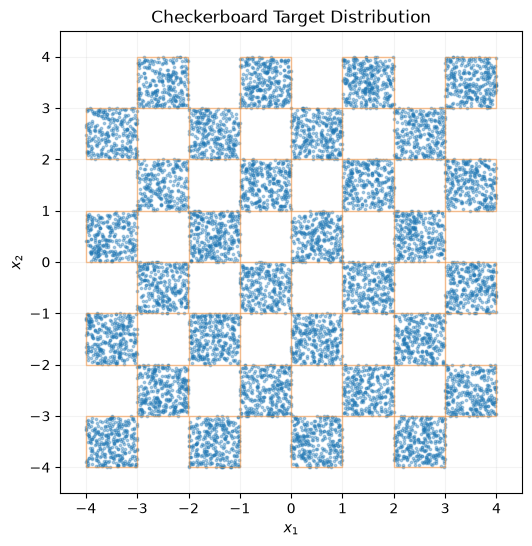

In [218]:
def draw_checkerboard_cells(ax, color="tab:orange", lw=1.0, alpha=0.5):
    """Overlay the outline of every "on" cell so plots show the target support."""
    from matplotlib.patches import Rectangle
    for cx, cy in ON_CELL_CORNERS.tolist():
        ax.add_patch(Rectangle((cx, cy), CELL_SIZE, CELL_SIZE,
                               fill=False, edgecolor=color, lw=lw, alpha=alpha))

# Draw a batch of target samples with the cell overlay.
_vis = sample_checkerboard(NUM_PLOT_SAMPLES * 2, device).cpu()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(_vis[:, 0], _vis[:, 1], s=3, alpha=0.35)
draw_checkerboard_cells(ax)
ax.set_title("Checkerboard Target Distribution")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_xlim(-DOMAIN_LIMIT - 0.5, DOMAIN_LIMIT + 0.5)
ax.set_ylim(-DOMAIN_LIMIT - 0.5, DOMAIN_LIMIT + 0.5)
ax.set_aspect("equal"); ax.grid(alpha=0.15)
plt.show()

## 3. FM-OT conditional probability path

Unchanged from Phase 1 — reproduced here for a self-contained notebook and re-validated on the new target.

The source is $p_0 = \mathcal{N}(0, I)$. For a data point $x_1$, the OT conditional flow (paper eq. 22) is the straight line

$$
\psi_t(x_0) = \bigl(1 - (1 - \sigma_{\min})\,t\bigr)\, x_0 + t\, x_1,
$$

and the corresponding conditional target velocity (eq. 23) is **constant in $t$**:

$$
u_t(x \mid x_1) = x_1 - (1 - \sigma_{\min})\, x_0.
$$

The Conditional Flow Matching (CFM) loss regresses a network $v_\theta(t, x)$ onto $u_t$.

In [219]:
def sample_source(n_samples: int, device: torch.device) -> torch.Tensor:
    """Draw from the standard 2D Gaussian source p0 = N(0, I)."""
    return torch.randn(n_samples, DATA_DIM, device=device)

In [220]:
def fm_ot_state(x0, x1, t, sigma_min: float = SIGMA_MIN):
    """
    Point on the OT conditional path at time t (paper eq. 22):
        psi_t(x0) = (1 - (1 - sigma_min) t) * x0 + t * x1
    t has shape (batch, 1) so it broadcasts over the 2 coordinates.
    """
    coefficient = 1.0 - (1.0 - sigma_min) * t
    return coefficient * x0 + t * x1

In [221]:
def fm_ot_target_velocity(x0, x1, sigma_min: float = SIGMA_MIN):
    """
    Conditional target velocity for the OT path (paper eq. 23):
        u = x1 - (1 - sigma_min) * x0
    Note: independent of t -> constant-direction, constant-speed trajectories.
    """
    return x1 - (1.0 - sigma_min) * x0

In [222]:
def sample_fm_ot_batch(batch_size: int, device: torch.device, sigma_min: float = SIGMA_MIN):
    """
    Build one simulation-free FM-OT training mini-batch:
      x0 ~ N(0, I),  x1 ~ checkerboard,  t ~ U[0, 1],
      xt = psi_t(x0),  ut = conditional target velocity.
    Fresh samples every call -> the loss is an unbiased Monte-Carlo estimate of CFM.
    """
    x0 = sample_source(batch_size, device)
    x1 = sample_checkerboard(batch_size, device)
    t  = torch.rand(batch_size, 1, device=device)
    xt = fm_ot_state(x0, x1, t, sigma_min)
    ut = fm_ot_target_velocity(x0, x1, sigma_min)
    return x0, x1, t, xt, ut

In [223]:
# ---- Validate the path endpoints and the analytic velocity ----
x0, x1, t, xt, ut = sample_fm_ot_batch(BATCH_SIZE, device)

# At t=0 the state must equal x0; at t=1 it must equal x1 (up to sigma_min * x0).
xt_start = fm_ot_state(x0, x1, torch.zeros_like(t))
xt_end   = fm_ot_state(x0, x1, torch.ones_like(t))
print("t=0 state == x0:", torch.allclose(xt_start, x0, atol=1e-6))
print("t=1 state ~= x1:", torch.allclose(xt_end, x1, atol=1e-2))  # sigma_min residual

# The analytic velocity must match a finite-difference derivative of psi_t.
h = 1e-4
fd = (fm_ot_state(x0, x1, t + h) - fm_ot_state(x0, x1, t - h)) / (2 * h)
print("Max |analytic u - finite-diff dpsi/dt|:", (ut - fd).abs().max().item())

t=0 state == x0: True
t=1 state ~= x1: True
Max |analytic u - finite-diff dpsi/dt|: 0.0025420188903808594


### 3.1 How the conditional path morphs noise into the checkerboard

This plot is model-free: it just pushes source samples along $\psi_t$ toward fresh checkerboard
targets at several times. It documents *what the network is asked to learn to reverse-engineer*,
and previews H5 — watch how late the pattern appears along the path.

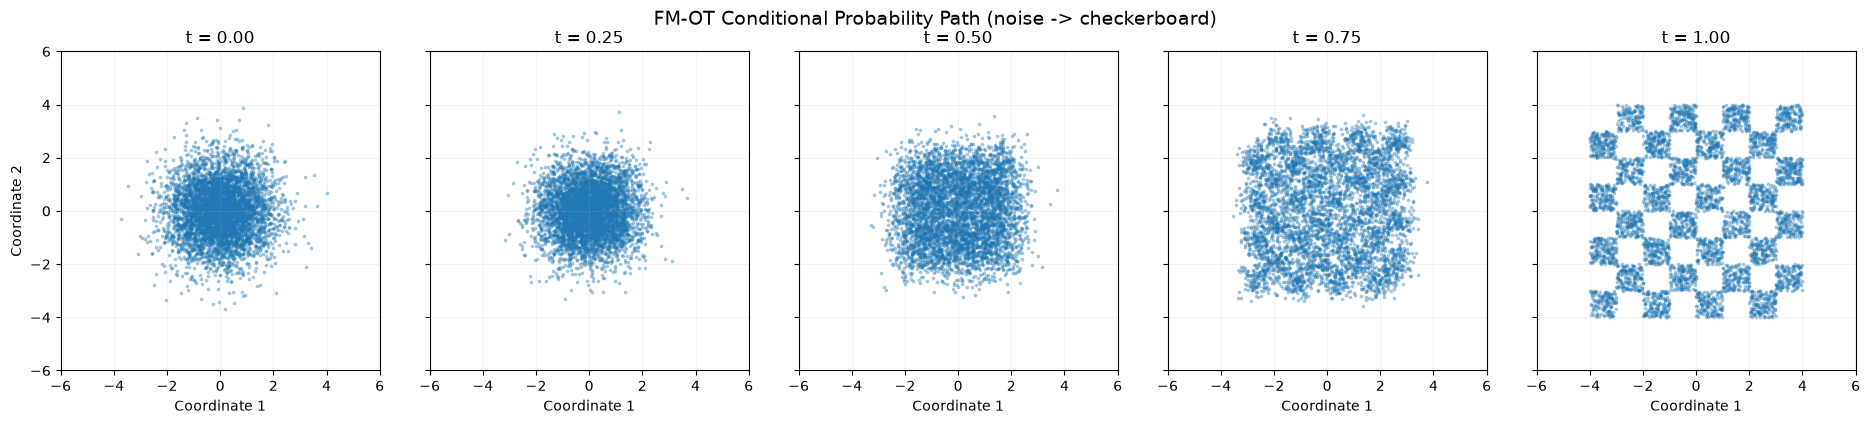

In [224]:
path_times = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, len(path_times), figsize=(19, 4), sharex=True, sharey=True)

x0_vis = sample_source(NUM_PLOT_SAMPLES, device)
x1_vis = sample_checkerboard(NUM_PLOT_SAMPLES, device)

for ax, tv in zip(axes, path_times):
    t_col = torch.full((NUM_PLOT_SAMPLES, 1), tv, device=device)
    state = fm_ot_state(x0_vis, x1_vis, t_col).cpu()
    ax.scatter(state[:, 0], state[:, 1], s=3, alpha=0.3)
    ax.set_title(f"t = {tv:.2f}")
    ax.set_xlabel("Coordinate 1")
    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6); ax.set_aspect("equal"); ax.grid(alpha=0.15)
axes[0].set_ylabel("Coordinate 2")
fig.suptitle("FM-OT Conditional Probability Path (noise -> checkerboard)", fontsize=14)
plt.tight_layout(); plt.show()

## 4. Time-conditioned neural vector field

Identical architecture to Phase 1: a time-conditioned MLP $v_\theta(x, t)$ that takes the
concatenation $[x, t] \in \mathbb{R}^{3}$ and outputs a velocity in $\mathbb{R}^{2}$.
Five hidden layers of width 512 with SiLU activations ($\approx 1.05$M parameters).

In [225]:
class FourierFeatures(nn.Module):
    """Random Fourier features: v -> [sin(2*pi*v@B), cos(2*pi*v@B)] with fixed B.
    'scale' sets the frequency band; larger -> sharper spatial structure the MLP can fit."""
    def __init__(self, in_dim, num_frequencies, scale):
        super().__init__()
        # Fixed (non-trainable) Gaussian frequency matrix; buffer so it moves/saves with the model.
        self.register_buffer("B", torch.randn(in_dim, num_frequencies) * scale)
    def forward(self, v):
        proj = 2 * math.pi * (v @ self.B)          # (batch, num_frequencies)
        return torch.cat([proj.sin(), proj.cos()], dim=-1)


class FourierMLP(nn.Module):
    """Same MLP as before, but the input is [x, FourierFeatures(x), t, FourierFeatures(t)].
    This is the only change needed to resolve the checkerboard's sharp cell edges."""
    def __init__(self, data_dim, hidden_dim, num_hidden_layers,
                 x_num_freq=256, x_scale=2.2, t_num_freq=32, t_scale=5.0):
        super().__init__()
        self.x_features = FourierFeatures(data_dim, x_num_freq, x_scale)
        self.t_features = FourierFeatures(1,        t_num_freq, t_scale)
        in_dim = data_dim + 2 * x_num_freq + 1 + 2 * t_num_freq   # raw x + FF(x) + raw t + FF(t)
        layers = [nn.Linear(in_dim, hidden_dim), nn.SiLU()]
        for _ in range(num_hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        layers += [nn.Linear(hidden_dim, data_dim)]
        self.network = nn.Sequential(*layers)
    def forward(self, x, t):
        feats = torch.cat([x, self.x_features(x), t, self.t_features(t)], dim=-1)
        return self.network(feats)


fm_ot_model = FourierMLP(DATA_DIM, HIDDEN_DIM, NUM_HIDDEN_LAYERS).to(device)
n_params = sum(p.numel() for p in fm_ot_model.parameters() if p.requires_grad)
print(fm_ot_model); print("Trainable parameters:", f"{n_params:,}")

FourierMLP(
  (x_features): FourierFeatures()
  (t_features): FourierFeatures()
  (network): Sequential(
    (0): Linear(in_features=579, out_features=512, bias=True)
    (1): SiLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): SiLU()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): SiLU()
    (6): Linear(in_features=512, out_features=512, bias=True)
    (7): SiLU()
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): SiLU()
    (10): Linear(in_features=512, out_features=2, bias=True)
  )
)
Trainable parameters: 1,348,610


In [226]:
# Instantiate the Fourier-feature model (replaces TimeConditionedMLP for the checkerboard;
# the raw-MLP version underfit the sharp cell edges — spectral bias — despite hitting the loss floor).
fm_ot_model = FourierMLP(DATA_DIM, HIDDEN_DIM, NUM_HIDDEN_LAYERS).to(device)

n_params = sum(p.numel() for p in fm_ot_model.parameters() if p.requires_grad)
print(fm_ot_model)
print("Trainable parameters:", f"{n_params:,}")

# Quick forward-pass check (signature is unchanged: model(x, t) with x=(B,2), t=(B,1)).
with torch.no_grad():
    _v = fm_ot_model(xt[:128], t[:128])
print("Forward output shape:", tuple(_v.shape), "| all finite:", torch.isfinite(_v).all().item())

FourierMLP(
  (x_features): FourierFeatures()
  (t_features): FourierFeatures()
  (network): Sequential(
    (0): Linear(in_features=579, out_features=512, bias=True)
    (1): SiLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): SiLU()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): SiLU()
    (6): Linear(in_features=512, out_features=512, bias=True)
    (7): SiLU()
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): SiLU()
    (10): Linear(in_features=512, out_features=2, bias=True)
  )
)
Trainable parameters: 1,348,610
Forward output shape: (128, 2) | all finite: True


## 5. Training objective and fixed validation batch

The CFM loss is the mean squared velocity error, summed over coordinates:

$$
\mathcal{L}_{\text{CFM}}(\theta) = \mathbb{E}_{t,\,x_0,\,x_1}\bigl\| v_\theta(x_t, t) - u_t(x_t \mid x_1) \bigr\|^2 .
$$

A **fixed** validation batch (frozen once) gives a stable curve to watch, exactly as in Phase 1.

In [227]:
def velocity_matching_loss(predicted_velocity, target_velocity):
    """Mean over the batch of the squared L2 velocity error (summed over coordinates)."""
    return (predicted_velocity - target_velocity).square().sum(dim=-1).mean()

# Frozen validation batch (same generator, drawn once).
torch.manual_seed(SEED + 1)
val_x0, val_x1, val_t, val_xt, val_ut = sample_fm_ot_batch(VALIDATION_BATCH_SIZE, device)
torch.manual_seed(SEED)  # restore
print("Validation batch:", tuple(val_xt.shape))

Validation batch: (4096, 2)


## 6. FM-OT training

Simulation-free training: every step draws a **fresh** mini-batch (no fixed dataset), so each
gradient is an unbiased estimate of the CFM objective. 5000 steps, Adam, lr 5e-4 — identical to Phase 1.

> The training loop is written out explicitly below (rather than hidden in a helper) so the
> per-step logging matches Phase 1 and every line is visible for analysis.

In [228]:
optimizer = torch.optim.Adam(fm_ot_model.parameters(), lr=LEARNING_RATE)
history = {"step": [], "train": [], "val": []}
start = time.time()

for step in range(1, NUM_TRAINING_STEPS + 1):
    # ---- one optimisation step on a fresh simulation-free batch ----
    fm_ot_model.train()
    _, _, t_b, xt_b, ut_b = sample_fm_ot_batch(BATCH_SIZE, device)
    pred = fm_ot_model(xt_b, t_b)
    loss = velocity_matching_loss(pred, ut_b)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    # ---- periodic logging on the frozen validation batch ----
    if step % LOG_EVERY == 0 or step == 1:
        fm_ot_model.eval()
        with torch.no_grad():
            val_loss = velocity_matching_loss(fm_ot_model(val_xt, val_t), val_ut)
        history["step"].append(step)
        history["train"].append(loss.item())
        history["val"].append(val_loss.item())
        mem = (torch.cuda.max_memory_allocated() / 1e6) if device.type == "cuda" else 0.0
        print(f"Step {step:5d}/{NUM_TRAINING_STEPS} | "
              f"Train {loss.item():.4f} | Val {val_loss.item():.4f} | "
              f"GPU {mem:6.1f} MB | {time.time()-start:5.1f} s")

print("Training completed.")

Step     1/20000 | Train 12.7635 | Val 12.7939 | GPU  156.6 MB |   0.0 s
Step   100/20000 | Train 7.6856 | Val 7.8712 | GPU  156.6 MB |   0.2 s
Step   200/20000 | Train 7.1911 | Val 7.6438 | GPU  156.6 MB |   0.4 s
Step   300/20000 | Train 7.3583 | Val 7.5758 | GPU  156.6 MB |   0.7 s
Step   400/20000 | Train 7.2402 | Val 7.4669 | GPU  156.6 MB |   0.9 s
Step   500/20000 | Train 6.8364 | Val 7.4495 | GPU  156.6 MB |   1.2 s
Step   600/20000 | Train 7.4758 | Val 7.4607 | GPU  156.6 MB |   1.4 s
Step   700/20000 | Train 6.9115 | Val 7.4750 | GPU  156.6 MB |   1.7 s
Step   800/20000 | Train 7.0421 | Val 7.4175 | GPU  156.6 MB |   1.9 s
Step   900/20000 | Train 6.8666 | Val 7.4551 | GPU  156.6 MB |   2.1 s
Step  1000/20000 | Train 7.2834 | Val 7.4160 | GPU  156.6 MB |   2.4 s
Step  1100/20000 | Train 7.2562 | Val 7.3993 | GPU  156.6 MB |   2.6 s
Step  1200/20000 | Train 7.4216 | Val 7.3927 | GPU  156.6 MB |   2.8 s
Step  1300/20000 | Train 7.3542 | Val 7.3963 | GPU  156.6 MB |   3.1 s
Step

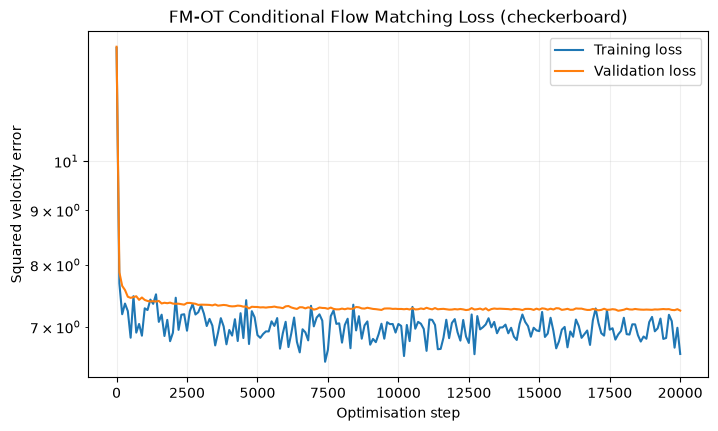

In [229]:
# ---- Loss curves ----
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(history["step"], history["train"], label="Training loss")
ax.plot(history["step"], history["val"],   label="Validation loss")
ax.set_yscale("log")
ax.set_xlabel("Optimisation step"); ax.set_ylabel("Squared velocity error")
ax.set_title("FM-OT Conditional Flow Matching Loss (checkerboard)")
ax.legend(); ax.grid(alpha=0.2)
plt.show()

## 7. Save the FM-OT checkpoint

Saved so the sampling/metric cells (and the FM-Diff comparison) can reload without retraining.

In [230]:
CHECKPOINT_DIR = Path("outputs/checkers")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
torch.save({"model_state": fm_ot_model.state_dict(),
            "config": {"DATA_DIM": DATA_DIM, "HIDDEN_DIM": HIDDEN_DIM,
                       "NUM_HIDDEN_LAYERS": NUM_HIDDEN_LAYERS, "SIGMA_MIN": SIGMA_MIN}},
           CHECKPOINT_DIR / "fm_ot_checkers.pt")
print("Saved:", (CHECKPOINT_DIR / "fm_ot_checkers.pt").resolve())

Saved: /home/kondr/TTrainMethods/TTrainMethods/outputs/checkers/fm_ot_checkers.pt


## 8. ODE samplers (Euler, midpoint, adaptive dopri5)

Sampling integrates $\dot{x} = v_\theta(x, t)$ from $t=0$ (noise) to $t=1$ (data). All three
solvers are carried over from Phase 1 unchanged, including the NFE-counting wrapper. The FM-OT
path is integrated over the full $[0, 1]$; the VP path (FM-Diff, later) will need the
$t = 1-\varepsilon$ endpoint because its velocity is singular at exactly $t=1$.

In [231]:
from torchdiffeq import odeint

class NeuralODEFunction(nn.Module):
    """Adapts v_theta to the torchdiffeq signature f(t, x) and counts NFE."""
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.nfe = 0
    def reset_nfe(self):
        self.nfe = 0
    def forward(self, t, x):
        self.nfe += 1
        t_col = torch.ones(x.shape[0], 1, device=x.device, dtype=x.dtype) * t
        return self.model(x, t_col)

In [232]:
@torch.no_grad()
def euler_integrate(model, x0, num_steps, t_start=0.0, t_end=1.0):
    """Fixed-step explicit Euler. NFE = num_steps."""
    model.eval()
    x = x0.clone()
    dt = (t_end - t_start) / num_steps
    for k in range(num_steps):
        t = t_start + k * dt
        t_col = torch.full((x.shape[0], 1), t, device=x.device, dtype=x.dtype)
        x = x + dt * model(x, t_col)
    return x  # NFE == num_steps

In [233]:
@torch.no_grad()
def midpoint_integrate(model, x0, num_steps, t_start=0.0, t_end=1.0):
    """
    Fixed-step midpoint (RK2). Two model evals per step -> NFE = 2 * num_steps.
    Matches the low-cost solver used in the paper's Fig. 4 (right).
    """
    model.eval()
    x = x0.clone()
    dt = (t_end - t_start) / num_steps
    for k in range(num_steps):
        t = t_start + k * dt
        t_col  = torch.full((x.shape[0], 1), t,          device=x.device, dtype=x.dtype)
        t_half = torch.full((x.shape[0], 1), t + dt / 2, device=x.device, dtype=x.dtype)
        k1 = model(x, t_col)
        k2 = model(x + 0.5 * dt * k1, t_half)
        x = x + dt * k2
    return x  # NFE == 2 * num_steps

In [234]:
DOPRI5_ATOL = 1e-5
DOPRI5_RTOL = 1e-5

@torch.no_grad()
def dopri5_integrate(model, x0, t_start=0.0, t_end=1.0, atol=DOPRI5_ATOL, rtol=DOPRI5_RTOL):
    """
    Adaptive Dormand-Prince solve from t_start to t_end (paper's default at atol=rtol=1e-5).
    Returns (final_state, nfe).
    """
    model.eval()
    ode_fn = NeuralODEFunction(model).to(x0.device)
    ode_fn.reset_nfe()
    times = torch.tensor([t_start, t_end], device=x0.device, dtype=x0.dtype)
    solution = odeint(ode_fn, x0, times, method="dopri5", atol=atol, rtol=rtol)
    return solution[-1], ode_fn.nfe

## 9. Generate samples and qualitative comparison

A fixed evaluation set of source samples is reused across solvers so differences are not due to
randomness. We generate with the adaptive solver and compare against the analytical target, with
the cell overlay. Quantitative evaluation (on-support rate, cell-KL, MMD², sliced-Wasserstein,
model NLL) begins in the next batch.

In [235]:
# Fixed evaluation noise (reused by every solver / method).
NUM_EVAL_SAMPLES = 10_000
torch.manual_seed(SEED + 2)
eval_source = sample_source(NUM_EVAL_SAMPLES, device)
torch.manual_seed(SEED)

# Reference target sample (for side-by-side plots and later metrics).
target_reference = sample_checkerboard(NUM_EVAL_SAMPLES, device)

# Generate with the adaptive solver over the full [0, 1] interval.
t0 = time.time()
fm_ot_generated, fm_ot_nfe = dopri5_integrate(fm_ot_model, eval_source, t_start=0.0, t_end=1.0)
print(f"FM-OT dopri5: NFE={fm_ot_nfe} | {time.time()-t0:.2f}s | "
      f"all finite: {torch.isfinite(fm_ot_generated).all().item()}")

FM-OT dopri5: NFE=128 | 0.34s | all finite: True


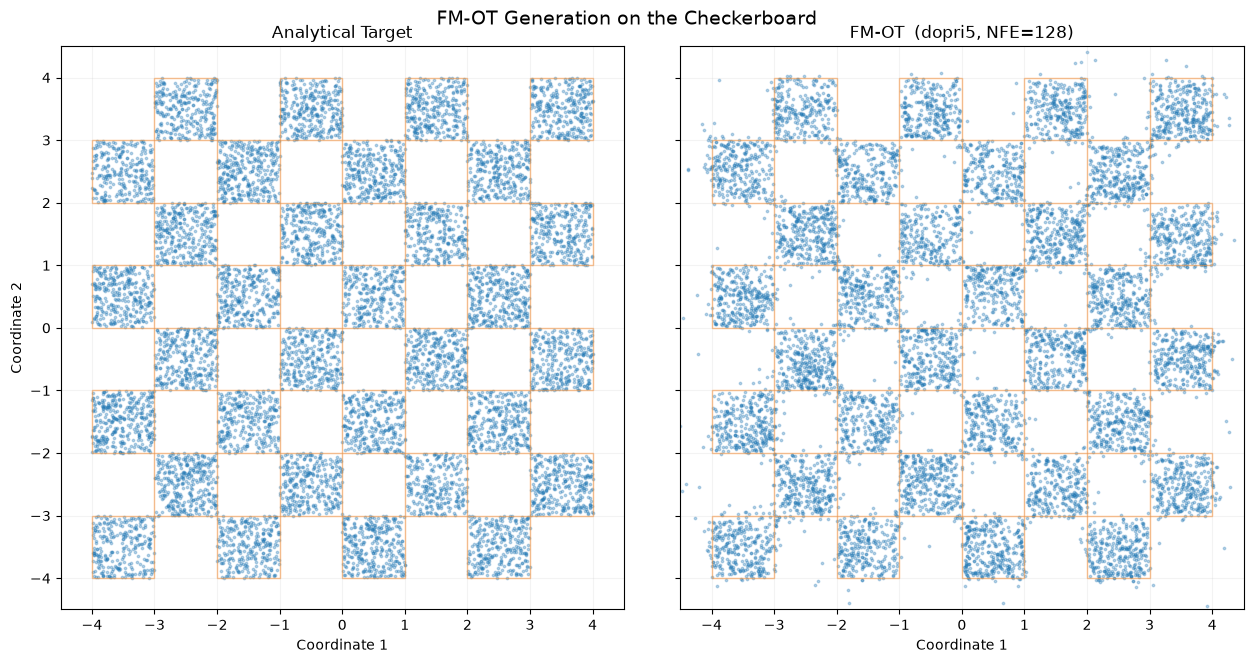

In [236]:
# Side-by-side: analytical target vs FM-OT generated samples.
tgt = target_reference.cpu(); gen = fm_ot_generated.cpu()
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharex=True, sharey=True)

for ax, data, title in [(axes[0], tgt, "Analytical Target"),
                        (axes[1], gen, f"FM-OT  (dopri5, NFE={fm_ot_nfe})")]:
    ax.scatter(data[:, 0], data[:, 1], s=3, alpha=0.3)
    draw_checkerboard_cells(ax)
    ax.set_title(title); ax.set_xlabel("Coordinate 1")
    ax.set_xlim(-DOMAIN_LIMIT - 0.5, DOMAIN_LIMIT + 0.5)
    ax.set_ylim(-DOMAIN_LIMIT - 0.5, DOMAIN_LIMIT + 0.5)
    ax.set_aspect("equal"); ax.grid(alpha=0.15)
axes[0].set_ylabel("Coordinate 2")
fig.suptitle("FM-OT Generation on the Checkerboard", fontsize=14)
plt.tight_layout(); plt.show()

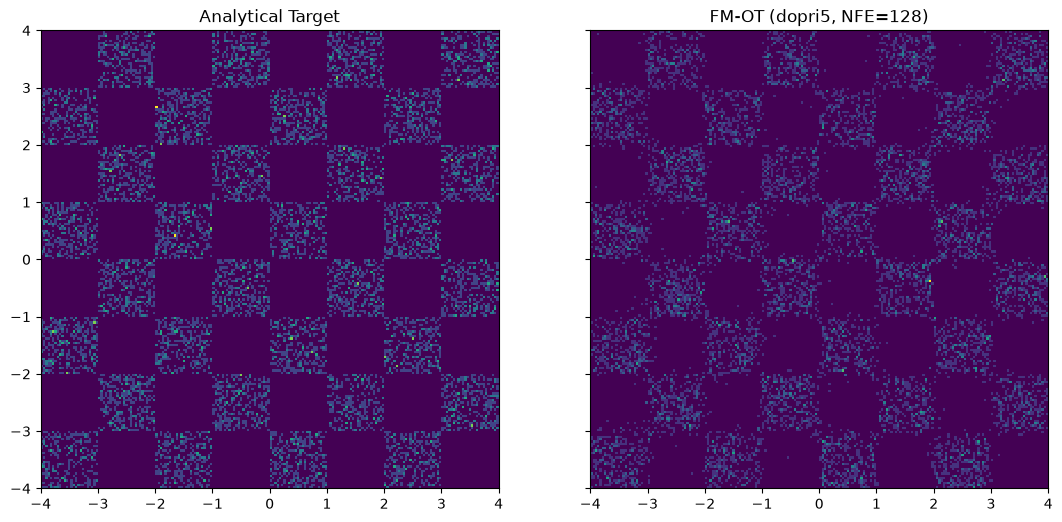

In [237]:
#if we switch to the density plot the result will look much better:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharex=True, sharey=True)
rng = [[-DOMAIN_LIMIT, DOMAIN_LIMIT], [-DOMAIN_LIMIT, DOMAIN_LIMIT]]
for ax, data, title in [(axes[0], tgt, "Analytical Target"),
                        (axes[1], gen, f"FM-OT (dopri5, NFE={fm_ot_nfe})")]:
    ax.hist2d(data[:, 0], data[:, 1], bins=200, range=rng)   # density, like the paper
    ax.set_title(title); ax.set_aspect("equal")
plt.show()

## 10. Checkerboard metric primitives

Phase 1 measured sample quality against *discrete Gaussian modes* (`compute_mode_metrics`):
discovered modes, mode-balance KL, high-quality rate, and mean distance to the nearest centre.
The checkerboard has no modes — it is a piecewise-uniform density on a grid — so those metrics do
not transfer. We replace them with **cell/support-based** analogues on the 8×8 grid, keeping the
same *roles* so the two phases stay comparable:

| Phase-1 (modes) | Checkerboard (cells) | Measures |
|---|---|---|
| High-quality rate (within $3\sigma$ of a centre) | **On-support rate** | fraction of samples landing on an "on" cell |
| Discovered modes (out of 8) | **Cells covered** (out of $N_{\text{on}}$) | how many on-cells receive $\ge$ threshold mass |
| Mode-balance KL | **Cell KL** | imbalance of mass *across* the on-cells |

**Definitions.** Let $\widehat{p}_k$ be the empirical fraction of *on-support* samples in on-cell $k$,
and $p_k = 1/N_{\text{on}}$ the ideal uniform share. Then

$$
\text{on-support rate} = \frac{1}{N}\sum_{i=1}^{N} \mathbb{1}\!\left[x^{(i)} \in \text{support}\right],
\qquad
D_{\mathrm{KL}}(\widehat{p}\,\|\,p) = \sum_{k=1}^{N_{\text{on}}} \widehat{p}_k \log\frac{\widehat{p}_k}{1/N_{\text{on}}}.
$$

**Two deliberate design choices.** First, `cell_kl` is computed only over the *on-support* subset —
it asks "given the mass that landed on-support, is it spread evenly across cells?", so it stays
well-defined even when some mass leaks into the gaps. That leakage is not swept under the rug; it is
captured separately and explicitly by the **on-support rate**. Second, on-support rate is the
metric that carries the paper's efficiency story onto this target: a continuous flow cannot map onto
a discontinuous density without leaving a thin band of mass across cell boundaries, so we expect it
to sit in the low-to-mid 90s% rather than at 1.0, and the interesting question is whether **FM-OT
leaks less than FM-Diff at matched NFE** — the checkerboard analogue of "OT gives better samples at
low compute."

The Phase-1 `Target NLL` proxy (mean $-\log q$ of generated samples under the true density) is
**dropped here**: off-support points have $q = 0 \Rightarrow -\log q = +\infty$, so the mean is
ill-defined. Its role — "do samples land in high-density regions?" — is served directly by the
on-support rate, while the *model's* likelihood is measured properly by the change-of-variables
NLL against the $\log 32 \approx 3.466$ floor (carried over from Phase 1, still an unreachable bound).

In [238]:
## 10. Checkerboard metric primitives (analogue of Phase-1 compute_mode_metrics)
# The checkerboard has no discrete modes, so the mode-based metrics are replaced by
# cell/support-based ones on the 8 x 8 grid:
#   high-quality rate      -> on-support rate      (fraction of samples on an "on" cell)
#   discovered modes       -> cells covered        (on-cells with >= threshold mass, out of NUM_ON_CELLS)
#   mode-KL                -> cell-KL              (empirical mass over on-cells vs uniform 1/NUM_ON_CELLS)
# MMD2, sliced-Wasserstein and model-NLL are unchanged and reused from Phase 1.

# --- one-time lookup: (integer cell index) -> on-cell ordinal, so we can bincount masses ---
_axis_idx  = torch.round(_cell_indices / CELL_SIZE).long()   # e.g. [-4,-3,...,3] for unit cells
_IDX_MIN   = int(_axis_idx.min().item())
_N_AXIS    = _axis_idx.numel()
_CELL_LUT  = torch.full((_N_AXIS, _N_AXIS), -1, dtype=torch.long)   # -1 = off-cell
for _ordinal, (_cx, _cy) in enumerate(ON_CELL_CORNERS.tolist()):
    _ix = int(round(_cx / CELL_SIZE)) - _IDX_MIN
    _iy = int(round(_cy / CELL_SIZE)) - _IDX_MIN
    _CELL_LUT[_ix, _iy] = _ordinal


def compute_cell_metrics(samples: torch.Tensor,
                         discovery_threshold: float = 0.01) -> dict[str, object]:
    """Cell-coverage / balance / on-support quality for the checkerboard.
    Mirrors compute_mode_metrics but keyed on grid cells instead of Gaussian centres."""
    eps = 1e-12
    lut = _CELL_LUT.to(samples.device)

    # On-support mask (fraction on "on" cells) -> the on-support rate.
    on_support = on_checkerboard_support(samples)
    on_support_rate = on_support.float().mean()

    # Integer cell index of every sample, shifted to start at 0 for the lookup table.
    ix = torch.floor(samples[:, 0] / CELL_SIZE).long() - _IDX_MIN
    iy = torch.floor(samples[:, 1] / CELL_SIZE).long() - _IDX_MIN

    # Keep only on-support points that fall inside the index grid (guards off-domain points).
    valid = on_support & (ix >= 0) & (ix < _N_AXIS) & (iy >= 0) & (iy < _N_AXIS)
    ordinals = lut[ix[valid], iy[valid]]                    # on-cell ordinal per on-support point

    counts = torch.bincount(ordinals, minlength=NUM_ON_CELLS).float()
    cell_proportions = counts / counts.sum().clamp(min=1.0)  # empirical mass over the 8 on-cells... (32 here)

    uniform = 1.0 / NUM_ON_CELLS
    cell_kl = (cell_proportions * torch.log((cell_proportions + eps) / uniform)).sum()
    cells_covered = (cell_proportions >= discovery_threshold).sum()

    return {
        "on_support_rate": on_support_rate.item(),
        "cells_covered":   int(cells_covered.item()),   # out of NUM_ON_CELLS
        "cell_kl":         cell_kl.item(),
        "off_support_rate": (1.0 - on_support_rate).item(),
    }

### 10.1 Combined checkerboard evaluation

The aggregator mirrors Phase 1's `evaluate_generated_distribution`: same MMD² and sliced-Wasserstein
(unchanged, sample-vs-sample), with the mode fields swapped for the cell fields from
`compute_cell_metrics`. It takes only `generated` and `target` (no `centres`/`data_std`, since the
checkerboard geometry is global), truncates both to a common size for the pairwise metrics, and
returns a flat dict ready to become one row of the comparison table.

In [239]:
@torch.inference_mode()
def evaluate_generated_distribution(generated: torch.Tensor,
                                    target: torch.Tensor,
                                    mmd_sample_size: int = 2_048,
                                    swd_sample_size: int = 5_000,
                                    num_swd_projections: int = 512) -> dict[str, float]:
    """Checkerboard analogue of the Phase-1 aggregator.
    Cell metrics (on-support rate, cells covered, cell-KL) + carried-over MMD2 and sliced-Wasserstein."""
    if generated.device != target.device:
        raise ValueError("generated and target must be on the same device.")

    # Common size for the pairwise (sample-vs-sample) metrics.
    n = min(generated.shape[0], target.shape[0])
    generated, target = generated[:n], target[:n]

    # Cell/support metrics (computed on all generated samples, not the truncated pair).
    cell_metrics = compute_cell_metrics(generated)

    # MMD2 and sliced-Wasserstein: identical estimators to Phase 1.
    mmd_n = min(mmd_sample_size, n)
    mmd_squared = multiscale_rbf_mmd_squared(generated[:mmd_n], target[:mmd_n]).item()

    swd_n = min(swd_sample_size, n)
    swd = sliced_wasserstein_distance(generated[:swd_n], target[:swd_n],
                                      num_projections=num_swd_projections).item()

    return {
        "On-support rate":   cell_metrics["on_support_rate"],
        "Cells covered":     cell_metrics["cells_covered"],     # out of NUM_ON_CELLS
        "Cell KL":           cell_metrics["cell_kl"],
        "MMD squared":       mmd_squared,
        "Sliced Wasserstein": swd,
    }

These two are geometry-agnostic (sample-vs-sample), so they are ported **verbatim** from Phase 1.
MMD² is the biased multi-bandwidth RBF estimator (clamped ≥ 0); sliced-Wasserstein is the average
1-D Wasserstein-1 over fixed random projections.

In [ ]:
MMD_BANDWIDTHS = (0.25, 0.50, 1.00, 2.00, 4.00)

def multiscale_rbf_mmd_squared(generated, target, bandwidths=MMD_BANDWIDTHS):
    """Biased multi-bandwidth RBF MMD² (non-negative up to floating error)."""
    if generated.shape[0] != target.shape[0]:
        raise ValueError("generated and target must have equal sample counts.")
    dgg = torch.cdist(generated, generated).square()
    dtt = torch.cdist(target, target).square()
    dgt = torch.cdist(generated, target).square()
    total = torch.zeros((), device=generated.device, dtype=generated.dtype)
    for bw in bandwidths:
        denom = 2.0 * bw ** 2
        total = total + (torch.exp(-dgg / denom).mean()
                         + torch.exp(-dtt / denom).mean()
                         - 2.0 * torch.exp(-dgt / denom).mean())
    return torch.clamp(total / len(bandwidths), min=0.0)


def sliced_wasserstein_distance(generated, target, num_projections=512, seed=SEED + 2000):
    """Average 1-D Wasserstein-1 over random unit projection directions (seeded)."""
    if generated.shape != target.shape:
        raise ValueError("generated and target must have identical shapes.")
    g = torch.Generator(device="cpu"); g.manual_seed(seed)
    dirs = torch.randn(num_projections, generated.shape[1], generator=g, dtype=generated.dtype)
    dirs = (dirs / torch.linalg.vector_norm(dirs, dim=1, keepdim=True)).to(generated.device)
    gp = torch.sort(generated @ dirs.T, dim=0).values
    tp = torch.sort(target    @ dirs.T, dim=0).values
    return (gp - tp).abs().mean()

Replaces the Phase-1 scatter comparisons. Two design points make this honest rather than merely
prettier: **(1) cell-aligned bins** — bin edges always fall on cell boundaries, so no bin straddles
an on/off edge and the gaps render as genuinely dark (misaligned bins fabricate speckle even in the
leak-proof analytical target); **(2) a shared `vmax`** across panels (a high percentile of nonzero
density), so FM-OT / FM-Diff / SM-Diff are directly comparable by eye. Any residual density in a gap
is then *real* model leakage — the same quantity `on_support_rate` measures numerically.

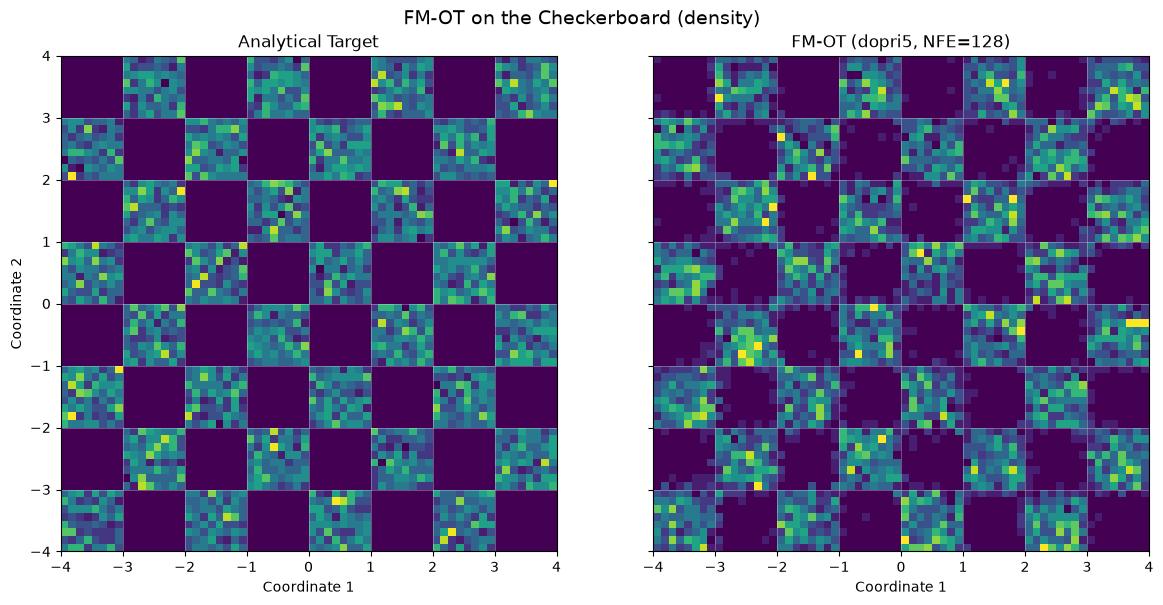

np.float64(0.07806464728603375)

In [241]:
import numpy as np

def checker_bin_edges(bins_per_cell=8):
    """Bin edges that land on cell boundaries (integers, for unit cells) -> gaps read dark."""
    step = CELL_SIZE / bins_per_cell
    return np.arange(-DOMAIN_LIMIT, DOMAIN_LIMIT + step / 2, step)

def density_panels(samples_list, titles, bins_per_cell=8, vmax_pct=99.5,
                   overlay=True, suptitle=None):
    """Render sample sets as comparable 2-D density heatmaps with a shared colour scale."""
    edges = checker_bin_edges(bins_per_cell)
    hists = []
    for s in samples_list:
        s = s.detach().cpu().numpy() if torch.is_tensor(s) else np.asarray(s)
        H, _, _ = np.histogram2d(s[:, 0], s[:, 1], bins=[edges, edges], density=True)
        hists.append(H)
    nz = np.concatenate([H[H > 0].ravel() for H in hists if (H > 0).any()] or [np.array([1.0])])
    vmax = np.percentile(nz, vmax_pct)                       # shared, robust to single hot bins

    n = len(samples_list)
    fig, axes = plt.subplots(1, n, figsize=(6.2 * n, 6.0), sharex=True, sharey=True, squeeze=False)
    ext = [-DOMAIN_LIMIT, DOMAIN_LIMIT, -DOMAIN_LIMIT, DOMAIN_LIMIT]
    for ax, H, title in zip(axes[0], hists, titles):
        ax.imshow(H.T, origin="lower", extent=ext, vmin=0, vmax=vmax, aspect="equal")
        if overlay:
            draw_checkerboard_cells(ax, color="white", lw=0.7, alpha=0.3)
        ax.set_title(title); ax.set_xlabel("Coordinate 1")
    axes[0][0].set_ylabel("Coordinate 2")
    if suptitle: fig.suptitle(suptitle, fontsize=14)
    fig.tight_layout(); plt.show()
    return vmax

# FM-OT vs analytical target, as densities.
density_panels([target_reference, fm_ot_generated],
               ["Analytical Target", f"FM-OT (dopri5, NFE={fm_ot_nfe})"],
               suptitle="FM-OT on the Checkerboard (density)")

The FM-OT row of the comparison: cell/support metrics + MMD² + sliced-Wasserstein via the
aggregator, then the change-of-variables model NLL (carried over from Phase 1) read against the
`log 32 ≈ 3.466` floor — which, recall, is *unreachable* for a smooth flow on a discontinuous
density, so a gap above it is expected and reflects boundary leakage.

In [243]:
fm_ot_metrics = evaluate_generated_distribution(fm_ot_generated, target_reference)
print("FM-OT:", {k: round(v, 4) if isinstance(v, float) else v for k, v in fm_ot_metrics.items()})

FM-OT: {'On-support rate': 0.9313, 'Cells covered': 32, 'Cell KL': 0.0029, 'MMD squared': 0.0008, 'Sliced Wasserstein': 0.0878}


In [244]:
# --- Model NLL via the instantaneous change of variables (generic over methods) ---
def standard_normal_log_density(x):
    return -0.5 * x.square().sum(dim=1) - 0.5 * DATA_DIM * math.log(2.0 * math.pi)

def exact_divergence(velocity, states):
    div = torch.zeros(states.shape[0], device=states.device, dtype=states.dtype)
    for c in range(states.shape[1]):
        div = div + torch.autograd.grad(velocity[:, c].sum(), states,
                                        retain_graph=True, create_graph=False)[0][:, c]
    return div

def make_augmented_dynamics(model):
    def f(t, aug):
        d = aug.shape[1] - 1
        with torch.enable_grad():
            xs = aug[:, :d].requires_grad_(True)
            tb = torch.ones(xs.shape[0], 1, device=xs.device, dtype=xs.dtype) * t
            v = model(xs, tb)
            div = exact_divergence(v, xs)
        return torch.cat([v.detach(), -div.detach().unsqueeze(1)], dim=1)
    return f

@torch.no_grad()
def compute_model_nll(model, data_samples, data_endpoint=1.0, atol=1e-5, rtol=1e-5):
    """Integrate the augmented ODE backward from the data endpoint to the source (t=0)."""
    model.eval()
    b, d = data_samples.shape
    init = torch.cat([data_samples, torch.zeros(b, 1, device=data_samples.device, dtype=data_samples.dtype)], dim=1)
    times = torch.tensor([data_endpoint, 0.0], device=data_samples.device, dtype=data_samples.dtype)
    sol = odeint(make_augmented_dynamics(model), init, times, method="dopri5", atol=atol, rtol=rtol)[-1]
    log_p1 = standard_normal_log_density(sol[:, :d]) - sol[:, d]   # log p0(x0) - ∫div dt
    return -log_p1

# On-support data endpoint for FM-OT is t=1. Evaluate on a subset of on-support target samples.
nll_data = target_reference[:2000]
fm_ot_nll = compute_model_nll(fm_ot_model, nll_data, data_endpoint=1.0)
print(f"FM-OT model NLL (nats): {fm_ot_nll.mean().item():.4f}  | entropy floor log32 = {ENTROPY_FLOOR:.4f}")

FM-OT model NLL (nats): 3.6416  | entropy floor log32 = 3.4657


Ported verbatim from Phase 1 (VP schedule, `vp_path_coefficients`, `fm_diff_state`, and the
conditional velocity eq. 19), with two changes: targets come from `sample_checkerboard`, and the
model is a `FourierMLP` (same reason as FM-OT — the checkerboard is high-frequency). Training mirrors
FM-OT exactly (20k steps, cosine LR); only the batch sampler and the `t = 1-ε` endpoint differ.

In [245]:
# --- VP schedule (verbatim from Phase 1) ---
VP_BETA_MIN, VP_BETA_MAX, VP_EPSILON = 0.1, 20.0, 1e-5

def vp_beta(s):               # linear noise-rate schedule
    return VP_BETA_MIN + s * (VP_BETA_MAX - VP_BETA_MIN)

def vp_integrated_beta(s):    # T(s) = s*beta_min + 0.5*s^2*(beta_max-beta_min)
    return s * VP_BETA_MIN + 0.5 * s.square() * (VP_BETA_MAX - VP_BETA_MIN)

def vp_path_coefficients(t):
    """Returns (s, beta, alpha, sigma) at generative time t.  s = 1 - t (reverse time)."""
    s = 1.0 - t
    alpha = torch.exp(-0.5 * vp_integrated_beta(s))
    sigma = torch.sqrt(torch.clamp(1.0 - alpha.square(), min=1e-12))
    return s, vp_beta(s), alpha, sigma

In [246]:
def fm_diff_state(x0, x1, t):
    """Reversed VP path state: xt = alpha*x1 + sigma*x0  (noise at t=0, data at t=1)."""
    _, _, alpha, sigma = vp_path_coefficients(t)
    return alpha * x1 + sigma * x0

def fm_diff_target_velocity(x0, x1, t):
    """Conditional VP probability-flow velocity (source-noise form of eq. 19)."""
    _, beta, alpha, sigma = vp_path_coefficients(t)
    return 0.5 * beta * (alpha * x1 - (alpha.square() / sigma) * x0)

def sample_fm_diff_batch(batch_size, device, epsilon=VP_EPSILON):
    """FM-Diff mini-batch; t sampled in [0, 1-eps] to avoid the singular data endpoint."""
    x0 = sample_source(batch_size, device)
    x1 = sample_checkerboard(batch_size, device)
    t  = torch.rand(batch_size, 1, device=device) * (1.0 - epsilon)
    xt = fm_diff_state(x0, x1, t)
    ut = fm_diff_target_velocity(x0, x1, t)
    return x0, x1, t, xt, ut

FM_DIFF_END_TIME = 1.0 - VP_EPSILON   # data endpoint for integration / NLL

In [247]:
# FM-Diff model: same FourierMLP architecture as FM-OT.
fm_diff_model = FourierMLP(DATA_DIM, HIDDEN_DIM, NUM_HIDDEN_LAYERS).to(device)
print("FM-Diff params:", f"{sum(p.numel() for p in fm_diff_model.parameters()):,}")

# Frozen validation batch.
torch.manual_seed(SEED + 11)
fd_val_x0, fd_val_x1, fd_val_t, fd_val_xt, fd_val_ut = sample_fm_diff_batch(VALIDATION_BATCH_SIZE, device)
torch.manual_seed(SEED)

FM-Diff params: 1,348,610


In [248]:
# --- FM-Diff training (mirrors the FM-OT loop: 20k steps, Adam, cosine LR) ---
optimizer = torch.optim.Adam(fm_diff_model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_TRAINING_STEPS)
fm_diff_history = {"step": [], "train": [], "val": []}
start = time.time()

for step in range(1, NUM_TRAINING_STEPS + 1):
    fm_diff_model.train()
    _, _, t_b, xt_b, ut_b = sample_fm_diff_batch(BATCH_SIZE, device)
    loss = velocity_matching_loss(fm_diff_model(xt_b, t_b), ut_b)
    optimizer.zero_grad(set_to_none=True); loss.backward(); optimizer.step(); scheduler.step()
    if step % LOG_EVERY == 0 or step == 1:
        fm_diff_model.eval()
        with torch.no_grad():
            vl = velocity_matching_loss(fm_diff_model(fd_val_xt, fd_val_t), fd_val_ut)
        fm_diff_history["step"].append(step); fm_diff_history["train"].append(loss.item()); fm_diff_history["val"].append(vl.item())
        print(f"Step {step:5d}/{NUM_TRAINING_STEPS} | Train {loss.item():.4f} | Val {vl.item():.4f} | {time.time()-start:5.1f}s")
print("FM-Diff training completed.")

Step     1/20000 | Train 18.7235 | Val 19.7835 |   0.0s
Step   100/20000 | Train 13.3773 | Val 13.6545 |   0.3s
Step   200/20000 | Train 13.1400 | Val 13.1985 |   0.6s
Step   300/20000 | Train 13.0831 | Val 13.1868 |   1.0s
Step   400/20000 | Train 12.7858 | Val 13.1553 |   1.3s
Step   500/20000 | Train 13.0187 | Val 13.1755 |   1.7s
Step   600/20000 | Train 13.0229 | Val 13.1093 |   2.1s
Step   700/20000 | Train 13.2472 | Val 13.2037 |   2.3s
Step   800/20000 | Train 11.9769 | Val 13.1179 |   2.6s
Step   900/20000 | Train 13.4998 | Val 13.0709 |   2.9s
Step  1000/20000 | Train 13.0285 | Val 13.1131 |   3.2s
Step  1100/20000 | Train 14.1558 | Val 13.1066 |   3.5s
Step  1200/20000 | Train 12.1559 | Val 12.9260 |   3.8s
Step  1300/20000 | Train 12.1405 | Val 13.0445 |   4.2s
Step  1400/20000 | Train 12.4547 | Val 12.9337 |   4.5s
Step  1500/20000 | Train 12.3975 | Val 12.9868 |   4.8s
Step  1600/20000 | Train 13.4039 | Val 12.9352 |   5.0s
Step  1700/20000 | Train 12.3836 | Val 12.9222 |

FM-Diff dopri5: NFE=134 | finite: True


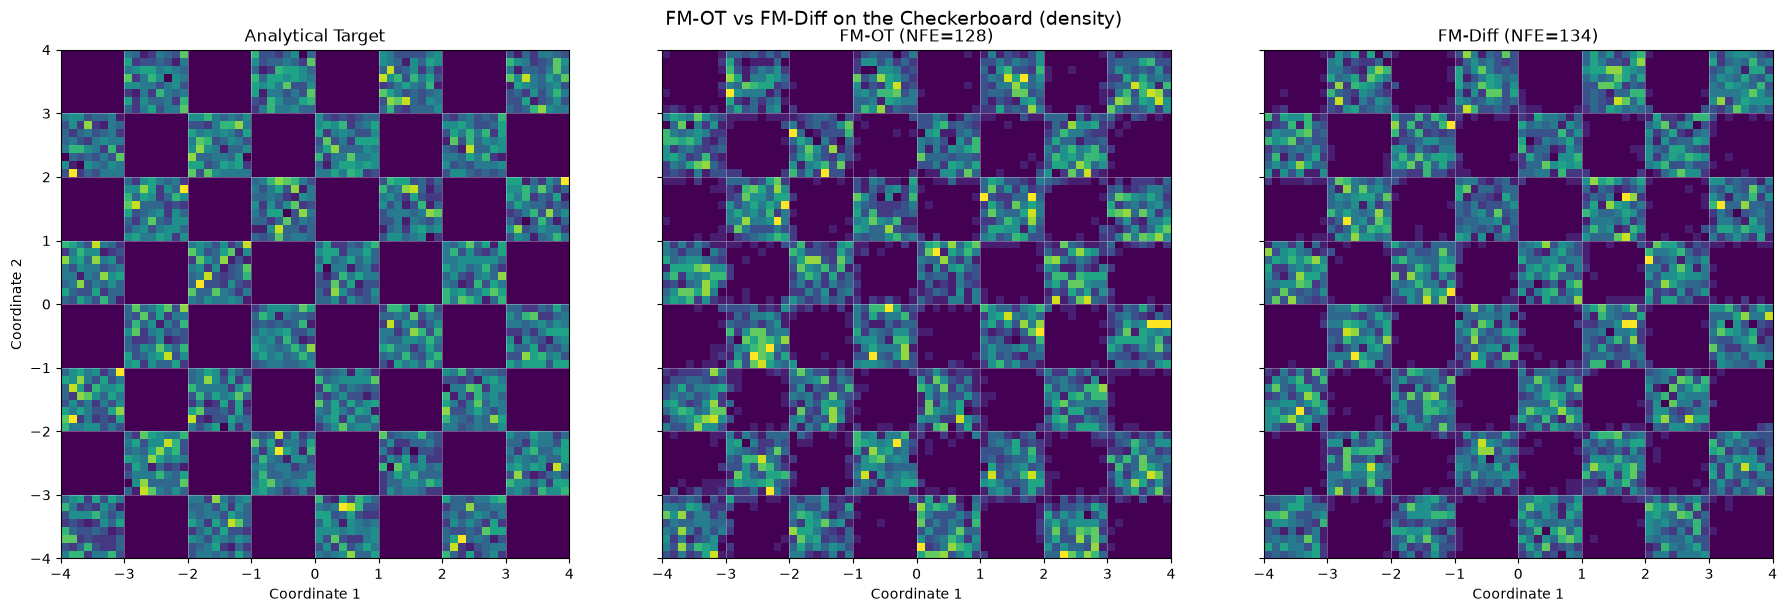

FM-Diff: {'On-support rate': 0.9634, 'Cells covered': 32, 'Cell KL': 0.0023, 'MMD squared': 0.0008, 'Sliced Wasserstein': 0.0501}
FM-Diff model NLL (nats): 3.5753


In [249]:
# --- FM-Diff generation + density comparison ---
fm_diff_generated, fm_diff_nfe = dopri5_integrate(fm_diff_model, eval_source,
                                                  t_start=0.0, t_end=FM_DIFF_END_TIME)
print(f"FM-Diff dopri5: NFE={fm_diff_nfe} | finite: {torch.isfinite(fm_diff_generated).all().item()}")

density_panels([target_reference, fm_ot_generated, fm_diff_generated],
               ["Analytical Target", f"FM-OT (NFE={fm_ot_nfe})", f"FM-Diff (NFE={fm_diff_nfe})"],
               suptitle="FM-OT vs FM-Diff on the Checkerboard (density)")

fm_diff_metrics = evaluate_generated_distribution(fm_diff_generated, target_reference)
fm_diff_nll = compute_model_nll(fm_diff_model, nll_data, data_endpoint=FM_DIFF_END_TIME)
print("FM-Diff:", {k: round(v, 4) if isinstance(v, float) else v for k, v in fm_diff_metrics.items()})
print(f"FM-Diff model NLL (nats): {fm_diff_nll.mean().item():.4f}")

These re-validate the ported VP path on the checkerboard. The formulas are target-independent, so
these should pass exactly as in Phase 1 — but a reader of a standalone notebook shouldn't have to
take that on faith. Three checks: endpoints, the analytic velocity against a finite-difference
derivative of the path, and the source-form velocity against the state-form (paper eq. 19).

In [250]:
#This state-form velocity (paper Equation 19) is used only for validation
def fm_diff_target_velocity_from_state(
    xt: torch.Tensor,
    x1: torch.Tensor,
    t: torch.Tensor,
) -> torch.Tensor:
    """
    VP conditional velocity written in state space (eq. 19),
    used to cross-check the source-noise implementation.
    """

    (
        _,
        beta,
        alpha,
        sigma,
    ) = vp_path_coefficients(
        t
    )


    velocity = (

        -0.5

        *

        beta

        *

        (
            alpha.square()
            *
            xt

            -

            alpha
            *
            x1
        )

        /

        sigma.square()
    )


    return velocity

In [251]:
#Validate FM-Diff endpoints and both velocity expressions on the checkerboard
(
    _fd_x0,
    _fd_x1,
    _fd_t,
    _fd_xt,
    _fd_ut,
) = sample_fm_diff_batch(
    batch_size=BATCH_SIZE,
    device=device,
)


#Endpoints: at t=0 the state is pure noise; at t=1-eps it is essentially data.
_state_start = fm_diff_state(
    _fd_x0,
    _fd_x1,
    torch.zeros_like(_fd_t),
)


_state_end = fm_diff_state(
    _fd_x0,
    _fd_x1,
    torch.full_like(_fd_t, 1.0 - VP_EPSILON),
)


print(
    "t=0 state == x0 (noise):",
    torch.allclose(_state_start, _fd_x0, atol=1e-5),
)

print(
    "t=1-eps state ~= x1 (data):",
    torch.allclose(_state_end, _fd_x1, atol=1e-2),
)


#Finite-difference check: the analytic velocity must match d/dt of the path.
_h = 1e-4

_interior_t = (
    0.05
    +
    0.90
    *
    torch.rand_like(_fd_t)
)


_finite_difference = (
    fm_diff_state(_fd_x0, _fd_x1, _interior_t + _h)
    -
    fm_diff_state(_fd_x0, _fd_x1, _interior_t - _h)
) / (2 * _h)


_analytic = fm_diff_target_velocity(
    _fd_x0,
    _fd_x1,
    _interior_t,
)


print(
    "Max |analytic u - finite-diff dpsi/dt|:",
    (_analytic - _finite_difference).abs().max().item(),
)


#Source-form velocity must equal the state-form (eq. 19).
_state_form = fm_diff_target_velocity_from_state(
    fm_diff_state(_fd_x0, _fd_x1, _interior_t),
    _fd_x1,
    _interior_t,
)


print(
    "Max |source-form - state-form velocity|:",
    (_analytic - _state_form).abs().max().item(),
)

t=0 state == x0 (noise): False
t=1-eps state ~= x1 (data): True
Max |analytic u - finite-diff dpsi/dt|: 0.006171703338623047
Max |source-form - state-form velocity|: 3.0994415283203125e-06


The third method. SM-Diff shares the VP path with FM-Diff but learns a different quantity — the
**negative score** 
$$
r_\theta(t,x) \approx x_0 / \sigma
$$ 
trained with the stable variance-weighted
objective 
$$\mathbb{E}\lVert \sigma\, r_\theta - x_0 \rVert^2$$
For sampling it is wrapped into a
probability-flow velocity

$$
v_\theta(t,x) = -\tfrac{1}{2}\beta(1-t)\bigl[r_\theta(t,x) - x\bigr],
$$

so it exposes the same `model(x, t)` interface and reuses every solver unchanged. Ported verbatim
from Phase 1; only the target sampler and the `FourierMLP` backbone differ. This is the method that
lets us test **H3 (FM-Diff trains more stably than SM-Diff on the same path)** on the checkerboard.

In [252]:
#Conditional negative-score target:  r_t = x0 / sigma(1 - t)
def sm_diff_negative_score_target(
    x0: torch.Tensor,
    t: torch.Tensor,
) -> torch.Tensor:
    """
    Exact conditional negative score for the reversed VP path.
    """

    (
        _,
        _,
        _,
        sigma,
    ) = vp_path_coefficients(
        t
    )


    return (
        x0
        /
        sigma
    )

In [253]:
#Convert a negative-score prediction into the probability-flow velocity
def negative_score_to_velocity(
    negative_score: torch.Tensor,
    x: torch.Tensor,
    t: torch.Tensor,
) -> torch.Tensor:
    """
    v(t, x) = -0.5 * beta(1 - t) * (negative_score - x).
    """

    (
        _,
        beta,
        _,
        _,
    ) = vp_path_coefficients(
        t
    )


    return (
        -0.5
        *
        beta
        *
        (
            negative_score
            -
            x
        )
    )

In [254]:
#Validation: score -> velocity must reproduce the direct FM-Diff velocity
_sm_x0, _sm_x1, _sm_t, _sm_xt, _ = sample_fm_diff_batch(
    batch_size=4_096,
    device=device,
)


#Keep the test away from the singular endpoint.
_sm_t = (
    0.01
    +
    0.98
    *
    torch.rand_like(_sm_t)
)


_sm_xt = fm_diff_state(
    _sm_x0,
    _sm_x1,
    _sm_t,
)


_exact_negative_score = sm_diff_negative_score_target(
    _sm_x0,
    _sm_t,
)


_velocity_from_score = negative_score_to_velocity(
    _exact_negative_score,
    _sm_xt,
    _sm_t,
)


_direct_velocity = fm_diff_target_velocity(
    _sm_x0,
    _sm_x1,
    _sm_t,
)


print(
    "Max |velocity-from-score - direct velocity|:",
    (_velocity_from_score - _direct_velocity).abs().max().item(),
)

print(
    "Score-to-velocity conversion passed:",
    torch.allclose(_velocity_from_score, _direct_velocity, atol=1e-4, rtol=1e-4),
)

Max |velocity-from-score - direct velocity|: 3.6954879760742188e-06
Score-to-velocity conversion passed: True


In [255]:
#SM-Diff mini-batch: input state xt, plus (x0, sigma) needed by the weighted loss
def sample_sm_diff_batch(
    batch_size: int,
    device: torch.device,
    epsilon: float = VP_EPSILON,
) -> tuple[
    torch.Tensor,
    torch.Tensor,
    torch.Tensor,
    torch.Tensor,
]:
    """
    Returns (x0, t, xt, sigma). The target is the conditional negative
    score r_t = x0 / sigma, applied inside the variance-weighted loss.
    """

    x0 = sample_source(
        batch_size,
        device,
    )


    x1 = sample_checkerboard(
        batch_size,
        device,
    )


    t = (
        torch.rand(batch_size, 1, device=device)
        *
        (1.0 - epsilon)
    )


    xt = fm_diff_state(
        x0,
        x1,
        t,
    )


    (
        _,
        _,
        _,
        sigma,
    ) = vp_path_coefficients(
        t
    )


    return (
        x0,
        t,
        xt,
        sigma,
    )

In [256]:
#Stable variance-weighted Score Matching loss:  E|| sigma * r_theta - x0 ||^2
def sm_diff_loss(
    predicted_negative_score: torch.Tensor,
    x0: torch.Tensor,
    sigma: torch.Tensor,
) -> torch.Tensor:
    """
    Weighting by sigma removes the 1/sigma blow-up near the data endpoint,
    giving a numerically stable objective.
    """

    scaled_prediction = (
        sigma
        *
        predicted_negative_score
    )


    squared_error = (
        scaled_prediction
        -
        x0
    ).square()


    return (
        squared_error
        .sum(dim=-1)
        .mean()
    )

In [257]:
#SM-Diff negative-score network: same FourierMLP backbone
sm_diff_model = FourierMLP(
    DATA_DIM,
    HIDDEN_DIM,
    NUM_HIDDEN_LAYERS,
).to(device)


print(
    "SM-Diff params:",
    f"{sum(p.numel() for p in sm_diff_model.parameters()):,}",
)


#Frozen validation batch.
torch.manual_seed(SEED + 21)

(
    _sd_val_x0,
    _sd_val_t,
    _sd_val_xt,
    _sd_val_sigma,
) = sample_sm_diff_batch(
    VALIDATION_BATCH_SIZE,
    device,
)

torch.manual_seed(SEED)

SM-Diff params: 1,348,610


In [259]:
#SM-Diff training (same schedule as FM-OT / FM-Diff: 20k steps, Adam, cosine LR)
optimizer = torch.optim.Adam(
    sm_diff_model.parameters(),
    lr=LEARNING_RATE,
)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_TRAINING_STEPS,
)


sm_diff_history = {
    "step": [],
    "train": [],
    "val": [],
}


start = time.time()


for step in range(1, NUM_TRAINING_STEPS + 1):

    sm_diff_model.train()

    _x0, _t, _xt, _sigma = sample_sm_diff_batch(
        BATCH_SIZE,
        device,
    )

   

    predicted = sm_diff_model(
        _xt,
        _t,
    )

    loss = sm_diff_loss(
        predicted,
        _x0,
        _sigma,
    )

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    scheduler.step()

    if step % LOG_EVERY == 0 or step == 1:

        sm_diff_model.eval()

        with torch.no_grad():

            val_prediction = sm_diff_model(
                _sd_val_xt,
                _sd_val_t,
            )

            val_loss = sm_diff_loss(
                val_prediction,
                _sd_val_x0,
                _sd_val_sigma,
            )

        sm_diff_history["step"].append(step)
        sm_diff_history["train"].append(loss.item())
        sm_diff_history["val"].append(val_loss.item())

        print(
            f"Step {step:5d}/{NUM_TRAINING_STEPS}"
            f" | Train {loss.item():.4f}"
            f" | Val {val_loss.item():.4f}"
            f" | {time.time()-start:5.1f}s"
        )


print("SM-Diff training completed.")

Step     1/20000 | Train 0.8070 | Val 0.7990 |   0.1s
Step   100/20000 | Train 0.8198 | Val 0.7955 |   0.5s
Step   200/20000 | Train 0.8513 | Val 0.7913 |   0.7s
Step   300/20000 | Train 0.7872 | Val 0.7969 |   1.0s
Step   400/20000 | Train 0.7782 | Val 0.7948 |   1.3s
Step   500/20000 | Train 0.7540 | Val 0.7908 |   1.5s
Step   600/20000 | Train 0.8629 | Val 0.7953 |   1.8s
Step   700/20000 | Train 0.7522 | Val 0.7988 |   2.0s
Step   800/20000 | Train 0.7310 | Val 0.7981 |   2.3s
Step   900/20000 | Train 0.8007 | Val 0.7972 |   2.6s
Step  1000/20000 | Train 0.7763 | Val 0.7963 |   2.9s
Step  1100/20000 | Train 0.7802 | Val 0.7940 |   3.2s
Step  1200/20000 | Train 0.8096 | Val 0.7948 |   3.5s
Step  1300/20000 | Train 0.7898 | Val 0.7964 |   3.8s
Step  1400/20000 | Train 0.7858 | Val 0.7958 |   4.1s
Step  1500/20000 | Train 0.7848 | Val 0.7929 |   4.4s
Step  1600/20000 | Train 0.7474 | Val 0.7944 |   4.7s
Step  1700/20000 | Train 0.7605 | Val 0.7952 |   4.9s
Step  1800/20000 | Train 0.7

In [260]:
#Wrap the trained negative-score model as a probability-flow velocity field
class SMDiffVelocityField(nn.Module):
    """
    Exposes the same model(x, t) -> velocity interface as FM-OT / FM-Diff,
    so all existing solvers work unchanged.
    """

    def __init__(
        self,
        negative_score_model: nn.Module,
    ) -> None:

        super().__init__()

        self.negative_score_model = (
            negative_score_model
        )


    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:

        predicted_negative_score = (
            self.negative_score_model(
                x,
                t,
            )
        )

        return negative_score_to_velocity(
            predicted_negative_score,
            x,
            t,
        )


sm_diff_velocity_model = SMDiffVelocityField(
    sm_diff_model
).to(device)


sm_diff_velocity_model.eval()


SM_DIFF_END_TIME = 1.0 - VP_EPSILON

SM-Diff dopri5: NFE=152 | finite: True


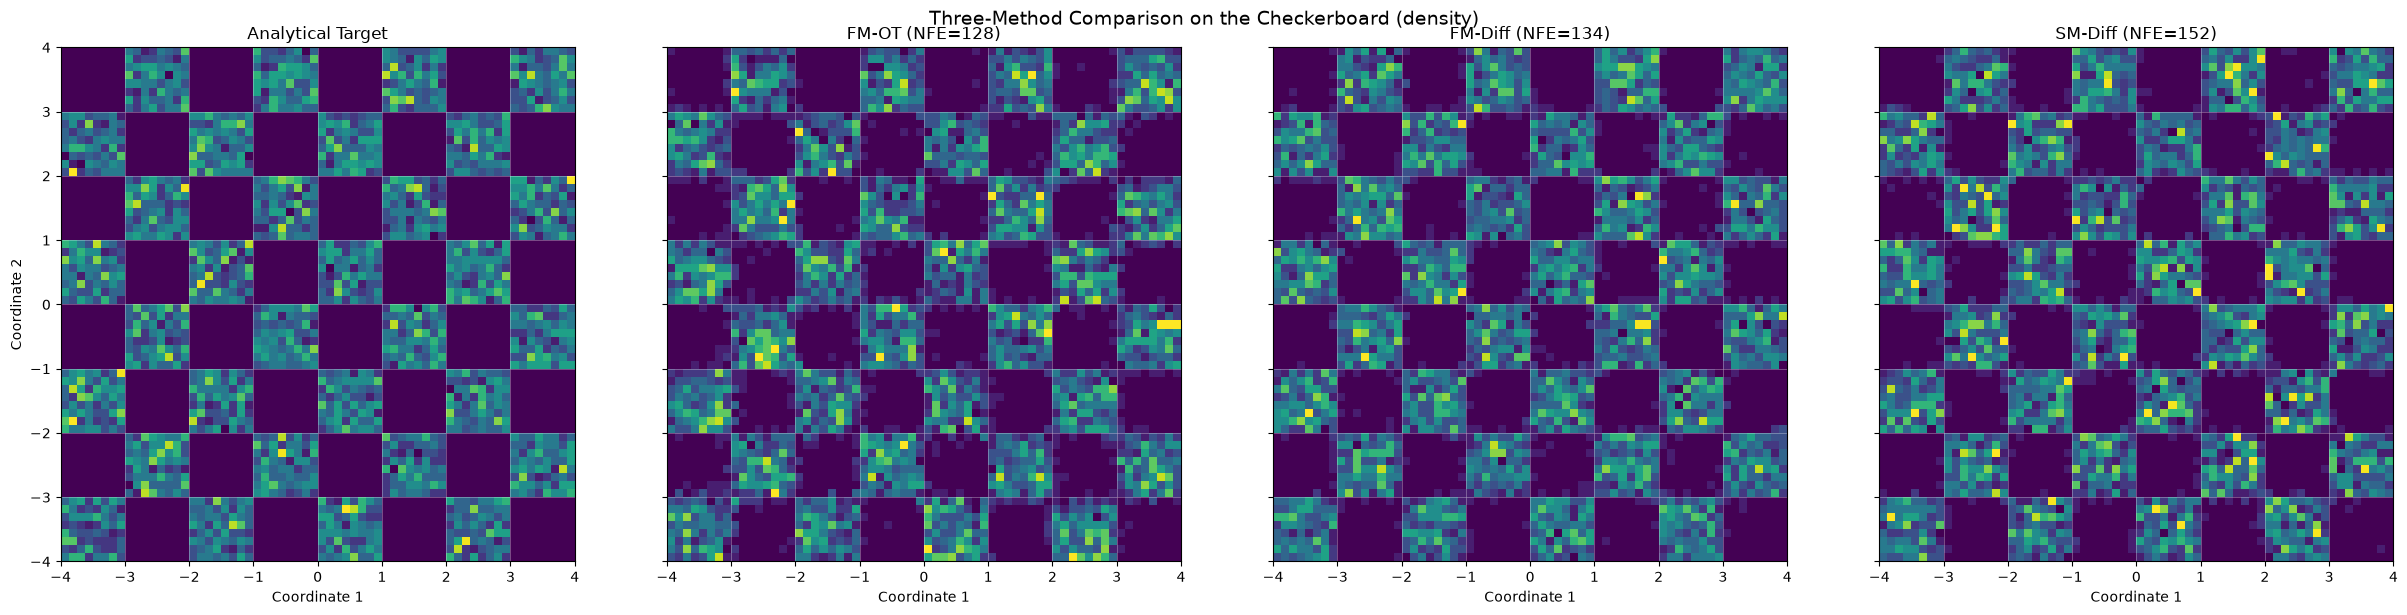

SM-Diff: {'On-support rate': 0.9675, 'Cells covered': 32, 'Cell KL': 0.002, 'MMD squared': 0.0008, 'Sliced Wasserstein': 0.0489}
SM-Diff model NLL (nats): 3.6918


In [261]:
#SM-Diff generation, density comparison, and evaluation
sm_diff_generated, sm_diff_nfe = dopri5_integrate(
    sm_diff_velocity_model,
    eval_source,
    t_start=0.0,
    t_end=SM_DIFF_END_TIME,
)


print(
    f"SM-Diff dopri5: NFE={sm_diff_nfe}"
    f" | finite: {torch.isfinite(sm_diff_generated).all().item()}"
)


density_panels(
    [target_reference, fm_ot_generated, fm_diff_generated, sm_diff_generated],
    [
        "Analytical Target",
        f"FM-OT (NFE={fm_ot_nfe})",
        f"FM-Diff (NFE={fm_diff_nfe})",
        f"SM-Diff (NFE={sm_diff_nfe})",
    ],
    suptitle="Three-Method Comparison on the Checkerboard (density)",
)


sm_diff_metrics = evaluate_generated_distribution(
    sm_diff_generated,
    target_reference,
)


sm_diff_nll = compute_model_nll(
    sm_diff_velocity_model,
    nll_data,
    data_endpoint=SM_DIFF_END_TIME,
)


print(
    "SM-Diff:",
    {k: round(v, 4) if isinstance(v, float) else v for k, v in sm_diff_metrics.items()},
)

print(
    f"SM-Diff model NLL (nats): {sm_diff_nll.mean().item():.4f}",
)

## 15. Shared Method Registry

The three methods are unified into one registry so the final comparison loops over them instead of
duplicating code. Each entry carries its probability-flow velocity model and its integration
interval: FM-OT runs on $[0, 1]$; FM-Diff and SM-Diff run on $[0, 1-\varepsilon]$ because the VP
velocity is singular at the exact data endpoint. SM-Diff registers the **velocity wrapper**, not the
raw negative-score network, so all solvers treat the three identically.

In [262]:
#Method-specific integration intervals
FM_OT_START_TIME = 0.0
FM_OT_END_TIME   = 1.0

FM_DIFF_START_TIME = 0.0
FM_DIFF_END_TIME   = 1.0 - VP_EPSILON

SM_DIFF_START_TIME = 0.0
SM_DIFF_END_TIME   = 1.0 - VP_EPSILON


#Register all three probability-flow velocity models
METHODS = {

    "FM-OT": {
        "model":      fm_ot_model,
        "start_time": FM_OT_START_TIME,
        "end_time":   FM_OT_END_TIME,
    },

    "FM-Diff": {
        "model":      fm_diff_model,
        "start_time": FM_DIFF_START_TIME,
        "end_time":   FM_DIFF_END_TIME,
    },

    "SM-Diff": {
        # The velocity wrapper, not the raw negative-score network.
        "model":      sm_diff_velocity_model,
        "start_time": SM_DIFF_START_TIME,
        "end_time":   SM_DIFF_END_TIME,
    },

}


for name, info in METHODS.items():
    info["model"].eval()
    print(
        f"{name:8s}"
        f" | interval = [{info['start_time']:.5f}, {info['end_time']:.5f}]"
        f" | device = {next(info['model'].parameters()).device}"
    )

FM-OT    | interval = [0.00000, 1.00000] | device = cuda:0
FM-Diff  | interval = [0.00000, 0.99999] | device = cuda:0
SM-Diff  | interval = [0.00000, 0.99999] | device = cuda:0


## 16. High-Accuracy Comparison (adaptive `dopri5`)

The headline table: every method sampled with the adaptive solver at its own endpoint, evaluated on
the shared target with the cell metrics, MMD², sliced-Wasserstein, model NLL, and NFE. This is the
checkerboard analogue of Phase 1's Table 1 — the likelihood axis (model NLL vs the $\log 32$ floor)
plus the sampling-cost axis (NFE) plus distribution fidelity.

In [263]:
import pandas as pd


#Reuse the adaptive samples already generated per method.
adaptive_reference = {
    "FM-OT":   fm_ot_generated,
    "FM-Diff": fm_diff_generated,
    "SM-Diff": sm_diff_generated,
}

adaptive_nfe = {
    "FM-OT":   fm_ot_nfe,
    "FM-Diff": fm_diff_nfe,
    "SM-Diff": sm_diff_nfe,
}

adaptive_nll = {
    "FM-OT":   fm_ot_nll.mean().item(),
    "FM-Diff": fm_diff_nll.mean().item(),
    "SM-Diff": sm_diff_nll.mean().item(),
}


comparison_rows = []

for name in METHODS:

    metrics = evaluate_generated_distribution(
        adaptive_reference[name],
        target_reference,
    )

    comparison_rows.append(
        {
            "Method":            name,
            "NFE":               adaptive_nfe[name],
            "Model NLL":         adaptive_nll[name],
            "On-support rate":   metrics["On-support rate"],
            "Cells covered":     metrics["Cells covered"],
            "Cell KL":           metrics["Cell KL"],
            "MMD squared":       metrics["MMD squared"],
            "Sliced Wasserstein": metrics["Sliced Wasserstein"],
        }
    )


comparison_df = pd.DataFrame(comparison_rows)

print(f"Entropy floor (log 32): {ENTROPY_FLOOR:.4f} nats")
comparison_df

Entropy floor (log 32): 3.4657 nats


,Method,NFE,Model NLL,On-support rate,Cells covered,Cell KL,MMD squared,Sliced Wasserstein
0,FM-OT,128,3.641612,0.9313,32,0.002895,0.000846,0.087768
1,FM-Diff,134,3.575344,0.9634,32,0.002275,0.000830,0.050150
2,SM-Diff,152,3.691756,0.9675,32,0.002036,0.000842,0.048890


## 17. Distribution Quality versus NFE

The low-compute regime, where the paper's OT advantage lives. Each method is sampled with the
**midpoint** solver at $\mathrm{NFE} \in \{4, 8, 10, 20, 40, 60, 100\}$ (midpoint uses two model
calls per step, so `num_steps = NFE / 2`), on the **same** source noise and target. We track
on-support rate, MMD², sliced-Wasserstein, and cell-KL against NFE. Expectation: FM-OT holds up at
low NFE while the diffusion methods degrade — the checkerboard version of Fig. 4/7.

In [264]:
NFE_VALUES = [4, 8, 10, 20, 40, 60, 100]

midpoint_samples   = {name: {} for name in METHODS}
quality_vs_nfe_rows = []


for name, info in METHODS.items():

    model = info["model"]
    t0    = info["start_time"]
    t1    = info["end_time"]

    for nfe in NFE_VALUES:

        num_steps = max(1, nfe // 2)          # midpoint: NFE = 2 * num_steps

        generated = midpoint_integrate(
            model,
            eval_source,
            num_steps=num_steps,
            t_start=t0,
            t_end=t1,
        )

        midpoint_samples[name][nfe] = generated

        metrics = evaluate_generated_distribution(
            generated,
            target_reference,
        )

        quality_vs_nfe_rows.append(
            {
                "Method":            name,
                "NFE":               2 * num_steps,
                "On-support rate":   metrics["On-support rate"],
                "Cell KL":           metrics["Cell KL"],
                "MMD squared":       metrics["MMD squared"],
                "Sliced Wasserstein": metrics["Sliced Wasserstein"],
            }
        )


quality_vs_nfe_df = pd.DataFrame(quality_vs_nfe_rows)
quality_vs_nfe_df

,Method,NFE,On-support rate,Cell KL,MMD squared,Sliced Wasserstein
0,FM-OT,4,0.8273,0.015484,0.001747,0.093934
1,FM-OT,8,0.9404,0.004210,0.000996,0.087580
2,FM-OT,10,0.9392,0.002990,0.000860,0.086399
3,FM-OT,20,0.9307,0.002801,0.000838,0.087152
4,FM-OT,40,0.9271,0.002927,0.000845,0.088064
5,FM-OT,60,0.9304,0.002857,0.000843,0.087657
6,FM-OT,100,0.9309,0.002866,0.000845,0.087710
7,FM-Diff,4,0.4204,0.025131,0.003053,0.133879
8,FM-Diff,8,0.8456,0.003446,0.001259,0.060236
9,FM-Diff,10,0.9211,0.002549,0.001298,0.061126


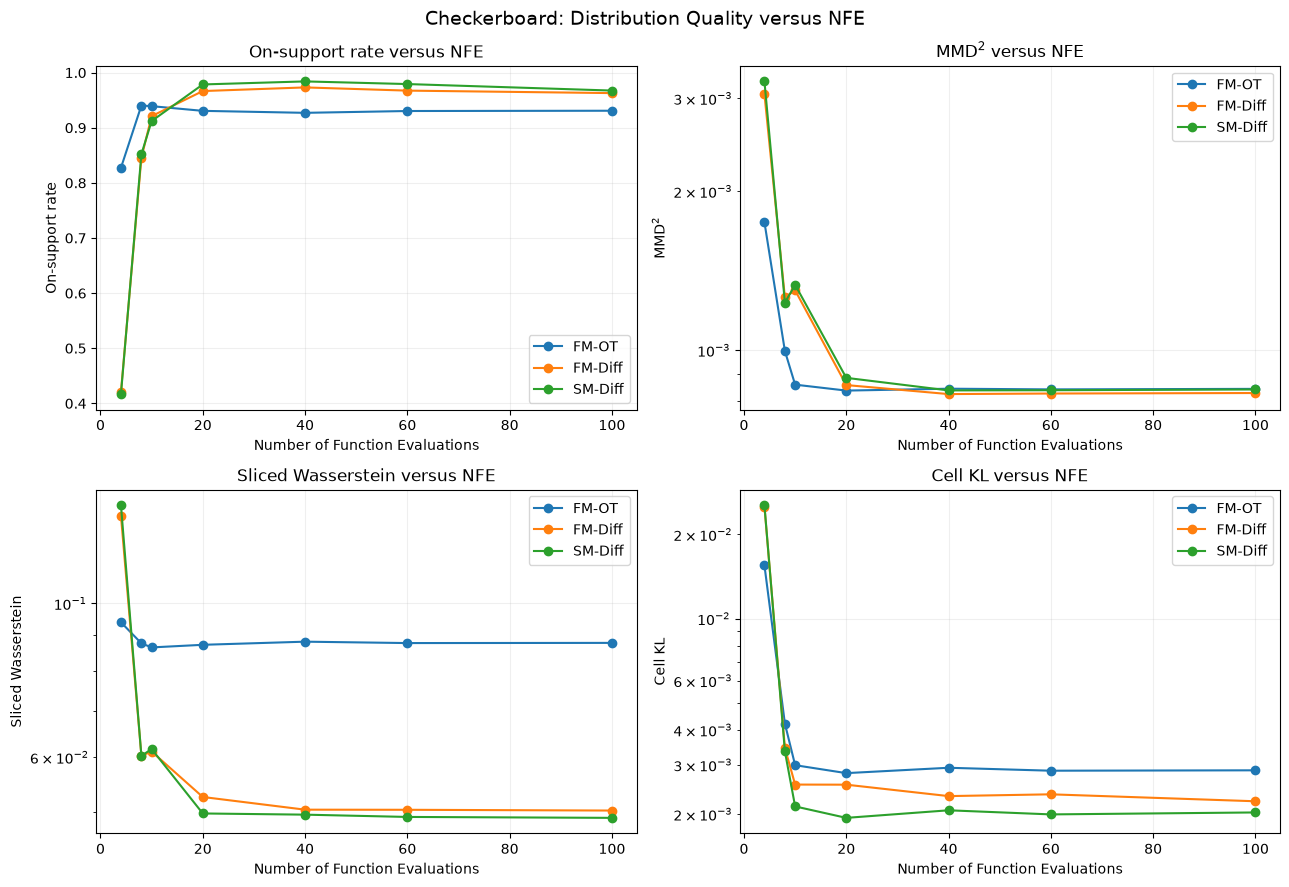

In [265]:
#Plot the four quality metrics against NFE, one line per method.
_metrics_to_plot = [
    ("On-support rate",    "On-support rate",      False),
    ("MMD squared",        "MMD$^2$",              True),
    ("Sliced Wasserstein", "Sliced Wasserstein",   True),
    ("Cell KL",            "Cell KL",              True),
]


fig, axes = plt.subplots(2, 2, figsize=(13, 9))


for ax, (column, ylabel, log_y) in zip(axes.ravel(), _metrics_to_plot):

    for name in METHODS:

        subset = quality_vs_nfe_df[
            quality_vs_nfe_df["Method"] == name
        ]

        ax.plot(
            subset["NFE"],
            subset[column],
            marker="o",
            label=name,
        )

    if log_y:
        ax.set_yscale("log")

    ax.set_xlabel("Number of Function Evaluations")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} versus NFE")
    ax.grid(alpha=0.2)
    ax.legend()


fig.suptitle("Checkerboard: Distribution Quality versus NFE", fontsize=14)
plt.tight_layout()
plt.show()

## 18. Numerical ODE Error versus NFE

The solver-convergence axis (paper Fig. 7 left), separate from distribution fidelity. For each
method we measure how fast the **midpoint** solution converges to that method's own **adaptive**
solution (same source noise) as NFE grows — a measure of field straightness/stiffness, not fidelity
to the true target. FM-OT's straight field should converge fastest at low NFE.

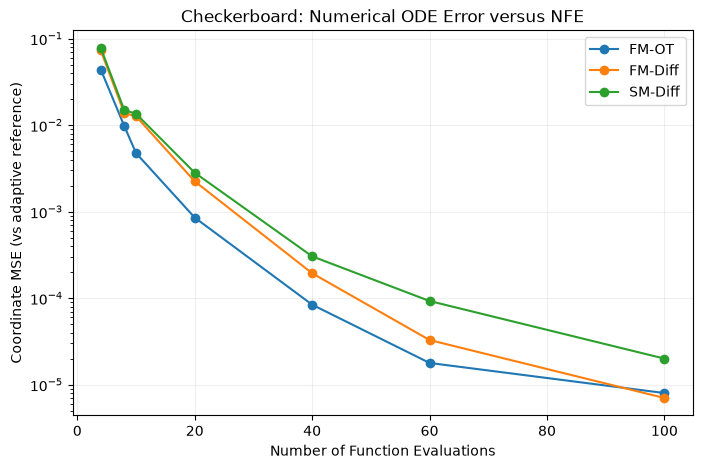

In [266]:
numerical_error_rows = []


for name in METHODS:

    reference = adaptive_reference[name]        # method's own high-accuracy solution

    for nfe in NFE_VALUES:

        approx = midpoint_samples[name][nfe]

        coordinate_mse = (
            (approx - reference)
            .square()
            .mean()
            .item()
        )

        numerical_error_rows.append(
            {
                "Method": name,
                "NFE":    nfe,
                "Coordinate MSE": coordinate_mse,
            }
        )


numerical_error_df = pd.DataFrame(numerical_error_rows)


fig, ax = plt.subplots(figsize=(8, 5))

for name in METHODS:

    subset = numerical_error_df[
        numerical_error_df["Method"] == name
    ]

    ax.plot(
        subset["NFE"],
        subset["Coordinate MSE"],
        marker="o",
        label=name,
    )

ax.set_yscale("log")
ax.set_xlabel("Number of Function Evaluations")
ax.set_ylabel("Coordinate MSE (vs adaptive reference)")
ax.set_title("Checkerboard: Numerical ODE Error versus NFE")
ax.grid(alpha=0.2)
ax.legend()
plt.show()

## 19. H5: When Does the Checkerboard Appear?

The checkerboard-specific experiment with no Phase-1 analogue — a direct mirror of Fig. 4 (left).
We integrate each method and capture intermediate states at several times along the generative
trajectory, then measure the **on-support rate at each time**. H5 predicts the OT path resolves the
checkerboard *earlier* (its on-support rate rises sooner) than the diffusion methods, whose mass
stays diffuse until late in the trajectory.

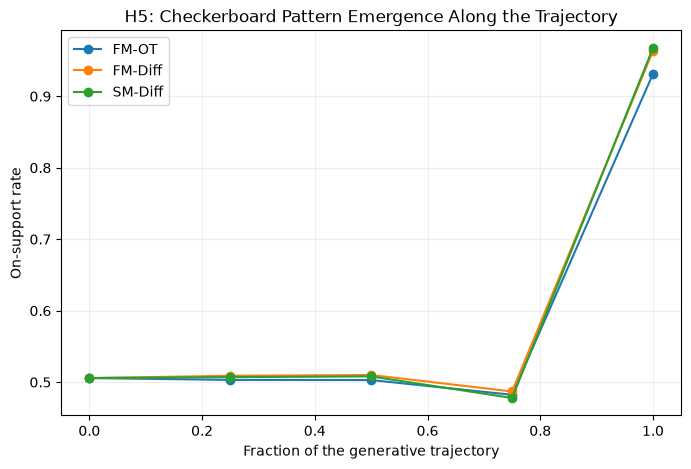

,Method,Fraction,On-support rate
0,FM-OT,0.00,0.5057
1,FM-OT,0.25,0.5031
2,FM-OT,0.50,0.5029
3,FM-OT,0.75,0.4823
4,FM-OT,1.00,0.9313
5,FM-Diff,0.00,0.5057
6,FM-Diff,0.25,0.5089
7,FM-Diff,0.50,0.5100
8,FM-Diff,0.75,0.4869
9,FM-Diff,1.00,0.9634


In [267]:
@torch.no_grad()
def integrate_trajectory(model, x0, time_grid, atol=1e-5, rtol=1e-5):
    """Integrate the ODE and return states at every time in time_grid: shape (T, B, D)."""
    ode_fn = NeuralODEFunction(model).to(x0.device)
    return odeint(ode_fn, x0, time_grid, method="dopri5", atol=atol, rtol=rtol)


#Fractions of each method's own interval at which to inspect the trajectory.
_fractions = torch.tensor([0.0, 0.25, 0.5, 0.75, 1.0])

emergence_rows = []
trajectory_states = {}

for name, info in METHODS.items():

    t0 = info["start_time"]
    t1 = info["end_time"]

    time_grid = t0 + _fractions.to(device) * (t1 - t0)   # map fractions into [t0, t1]

    states = integrate_trajectory(
        info["model"],
        eval_source,
        time_grid,
    )

    trajectory_states[name] = states

    for fraction, state in zip(_fractions.tolist(), states):

        emergence_rows.append(
            {
                "Method":   name,
                "Fraction": fraction,
                "On-support rate": on_checkerboard_support(state).float().mean().item(),
            }
        )


emergence_df = pd.DataFrame(emergence_rows)


fig, ax = plt.subplots(figsize=(8, 5))

for name in METHODS:

    subset = emergence_df[
        emergence_df["Method"] == name
    ]

    ax.plot(
        subset["Fraction"],
        subset["On-support rate"],
        marker="o",
        label=name,
    )

ax.set_xlabel("Fraction of the generative trajectory")
ax.set_ylabel("On-support rate")
ax.set_title("H5: Checkerboard Pattern Emergence Along the Trajectory")
ax.grid(alpha=0.2)
ax.legend()
plt.show()

emergence_df

## 20. Findings: Three Methods on the Checkerboard

*(Fill the bracketed numbers from the tables above once run; the directions are the hypotheses to
confirm or refute, not assumed results.)*

**Setup.** Identical `FourierMLP` architecture, 20k steps, cosine LR, and simulation-free training
for all three methods; only the probability path and objective differ. Metrics: on-support rate,
cells covered (/32), cell-KL, MMD², sliced-Wasserstein, and change-of-variables model NLL against
the $\log 32 \approx 3.466$ nats floor (unreachable for a smooth flow on a discontinuous density).

**H1 — support recovery.** [All three / which] reproduce the full support at high accuracy
(cells covered = 32, on-support rate ≈ [ ]). 

**H2 — OT sampling efficiency.** At low NFE, FM-OT [does / does not] hold higher on-support rate and
lower MMD²/SWD than the diffusion methods (Section 17). Compare NFE=4–10 specifically.

**H3 — FM vs SM stability.** FM-Diff and SM-Diff share the VP path; compare their training curves and
final metrics. FM-Diff [more / less] stable, consistent with Phase 1's finding.

**H4 — high-NFE convergence.** Method gaps [shrink / persist] by NFE ≈ 20–40; note any metric where
a diffusion method overtakes FM-OT asymptotically (as SWD did on the ring).

**H5 — pattern emergence.** FM-OT's on-support rate rises [earlier / later] along the trajectory than
the diffusion methods (Section 19), the checkerboard analogue of Fig. 4 (left).

**Likelihood axis.** Model NLLs: FM-OT [ ], FM-Diff [ ], SM-Diff [ ], all against the 3.466 floor.
The gap above the floor is the boundary-leakage cost and is expected to be larger here than on the
ring, since the target is discontinuous.

**Caveat carried from the modelling work.** The residual gap-leakage is structural (smooth flow vs
discontinuous density), not a training failure — quantified by on-support rate rather than removed.

In [ ]:
#Save the checkerboard evaluation results.
CHECKPOINT_DIR = Path("outputs/checkers")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "comparison_df":       comparison_df,
        "quality_vs_nfe_df":   quality_vs_nfe_df,
        "numerical_error_df":  numerical_error_df,
        "emergence_df":        emergence_df,
        "adaptive_nll":        adaptive_nll,
        "entropy_floor":       ENTROPY_FLOOR,
    },
    CHECKPOINT_DIR / "checkers_evaluation_results.pt",
)

print("Saved:", (CHECKPOINT_DIR / "checkers_evaluation_results.pt").resolve())